# Project 2 : supervised learning

## Data cleaning


**Environnement recommandé** : Ce notebook nécessite un GPU pour l'entraînement de DistilBERT. Il est conseillé de l'exécuter sur **Google Colab** (Runtime → Modifier le type d'exécution → GPU T4). L'exécution en local est possible mais DistilBERT sera très lent sans GPU (1–2h).


- Je connecte mon dossier drive du projet avec google colab ( à mttre en commentaire ou adapter si besoin)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/assurance-review')

Mounted at /content/drive


In [2]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc, torch
gc.collect()
torch.cuda.empty_cache()
print(f"Mémoire GPU libre : {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

Mémoire GPU libre : 15.53 GB


In [3]:
import pandas as pd
filePath = "datas"
avis1 = pd.read_excel(f"{filePath}/avis_1_traduit.xlsx")
print(avis1.shape)
avis1.head()

(1000, 11)


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN
1,4,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN
2,5,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN
3,4,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN
4,1,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN


In [4]:
avis2 = pd.read_excel(f"{filePath}/avis_2_traduit.xlsx")
avis2.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1,fatty58-63644,pour vous assurez tout est bon pour vous rembo...,MAAF,auto,train,28/04/2018,01/04/2018,To make sure everything is good to reimburse y...,NaN,NaN
1,1,yane94-101845,Ça fait deux ans que je suis client chez activ...,Active Assurances,auto,train,25/12/2020,01/12/2020,It's been two years that I have been a custome...,NaN,NaN
2,1,vanilla-87914,"Bonjour, après mettre fait accrocher ma voitur...",AXA,auto,train,03/03/2020,01/03/2020,"Hello, after putting my car hanging by a truck...",NaN,NaN
3,5,christophe-h-116471,J'ai divisé mon assurance auto par 2. Et en pl...,Direct Assurance,auto,train,09/06/2021,01/06/2021,I divided my car insurance by 2. and in additi...,NaN,NaN
4,4,taberlus-126856,Lissa est une personne accueillante et très à ...,Santiane,sante,train,06/08/2021,01/08/2021,Lissa is a welcoming person and very attentive...,NaN,NaN


**Remarque**: Les fichiers ont l'air de se ressembler en terme de structure, on va donc faire une méthode qui concatène tous les fichiers avis xlsx.

In [5]:
df_avis = avis1 # on commence avec le premier fichier puis on concatenera
nb_file = 35 # on a 35 fichier avis

for i in range(2, nb_file + 1):
    try:
        df_inter = pd.read_excel(f"{filePath}/avis_{i}_traduit.xlsx")
        if not df_inter.empty:
            df_avis = pd.concat([df_avis, df_inter])
    except:
        print(f"Pas de fichier avis_{i}_traduit.xlsx existant")

df_avis = df_avis.reset_index(drop=True)
df_avis.shape

(34435, 11)

In [6]:
# On enregistre le dataset
df_avis.to_csv("datas/avis.csv")

### On inspecte les colonnes, leurs types et les valeurs manquantes

In [7]:
df_avis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24104 non-null  float64
 1   auteur            34434 non-null  object 
 2   avis              34435 non-null  object 
 3   assureur          34435 non-null  object 
 4   produit           34435 non-null  object 
 5   type              34435 non-null  object 
 6   date_publication  34435 non-null  object 
 7   date_exp          34435 non-null  object 
 8   avis_en           34433 non-null  object 
 9   avis_cor          435 non-null    object 
 10  avis_cor_en       431 non-null    object 
dtypes: float64(1), object(10)
memory usage: 2.9+ MB


**Remarque**:
- Les types ont l'air ok, on peut tout de même transformer les dates en type date.
- Valeurs manquantes :
    - avis, assureur, produit, type, date_publication, date_exp : complets (0 valeurs manquantes)
	- auteur : 1 seule valeur manquante, négligeable
    - note : environ 30% de valeurs manquantes -> à traiter selon la tâche (imputation, suppression ou ignorer)
    - avis_en : presque complet, juste 2 manquants
    - avis_cor : Très peu rempli (environ 1,3%) -> probablement une correction orthographique partielle
    - avis_cor_en : pareil que avis_cor, c'est sa version traduite

In [8]:
# date to datetime
df_avis['date_publication'] = pd.to_datetime(df_avis['date_publication'], format="%d/%m/%Y")
df_avis['date_exp'] = pd.to_datetime(df_avis['date_exp'], format="%d/%m/%Y")
df_avis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   note              24104 non-null  float64       
 1   auteur            34434 non-null  object        
 2   avis              34435 non-null  object        
 3   assureur          34435 non-null  object        
 4   produit           34435 non-null  object        
 5   type              34435 non-null  object        
 6   date_publication  34435 non-null  datetime64[ns]
 7   date_exp          34435 non-null  datetime64[ns]
 8   avis_en           34433 non-null  object        
 9   avis_cor          435 non-null    object        
 10  avis_cor_en       431 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(8)
memory usage: 2.9+ MB


#### Dataset pour le modèle supervisé
**Gestion des valeurs manquantes**:
- note : on supprime les lignes vides pour le modèle supervisé car on souhaite prédire les étoiles. Si on impute on risque de biaiser le modèle

In [9]:
df_supervised = df_avis.dropna(subset=['note']).reset_index(drop=True)
df_supervised.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24104 entries, 0 to 24103
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   note              24104 non-null  float64       
 1   auteur            24103 non-null  object        
 2   avis              24104 non-null  object        
 3   assureur          24104 non-null  object        
 4   produit           24104 non-null  object        
 5   type              24104 non-null  object        
 6   date_publication  24104 non-null  datetime64[ns]
 7   date_exp          24104 non-null  datetime64[ns]
 8   avis_en           24103 non-null  object        
 9   avis_cor          0 non-null      object        
 10  avis_cor_en       0 non-null      object        
dtypes: datetime64[ns](2), float64(1), object(8)
memory usage: 2.0+ MB


In [10]:
# On regarde la distribution des notes pour voir si c'est équilibré
df_supervised['note'].value_counts().sort_index()

,count
note,
1.0,7271
2.0,3716
3.0,3382
4.0,4885
5.0,4850


**Remarque**: La distribution est relativement équilibrée, ce qui est une bonne nouvelle pour la modélisation

Pour le dataset supervisé il reste quelque valeurs manquantes négligeables (auteur, avis_en), on peut les retirer. De plus, les colonnes `corr` ne servent plus.

In [11]:
df_supervised.drop(columns=['avis_cor', 'avis_cor_en'], inplace=True)

In [12]:
df_supervised.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24104 entries, 0 to 24103
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   note              24104 non-null  float64       
 1   auteur            24103 non-null  object        
 2   avis              24104 non-null  object        
 3   assureur          24104 non-null  object        
 4   produit           24104 non-null  object        
 5   type              24104 non-null  object        
 6   date_publication  24104 non-null  datetime64[ns]
 7   date_exp          24104 non-null  datetime64[ns]
 8   avis_en           24103 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 1.7+ MB


In [13]:
df_supervised = df_supervised.dropna(subset=['auteur', 'avis_en'])
df_supervised.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24102 entries, 0 to 24103
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   note              24102 non-null  float64       
 1   auteur            24102 non-null  object        
 2   avis              24102 non-null  object        
 3   assureur          24102 non-null  object        
 4   produit           24102 non-null  object        
 5   type              24102 non-null  object        
 6   date_publication  24102 non-null  datetime64[ns]
 7   date_exp          24102 non-null  datetime64[ns]
 8   avis_en           24102 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 1.8+ MB


Le dataset pour la supervisé est clean, on peut le sauvegarder

In [14]:
df_supervised.to_csv('datas/data_supervised.csv')

#### Dataset pour le modèle non supervisé

Analysons les colonnes `cor`pour avoir une idée de ce qu'elles apportent

In [15]:
import numpy as np
pd.set_option('display.max_colwidth', None)
df_avis[['avis', 'avis_cor']][df_avis['avis_cor'].notna()]

,avis,avis_cor
34000,Assurance qui met les clients en difficultés. Plusieurs semaines d'attente pour pour le paiement lié à mon contrat maintien de salaire et toujours rien. Des accusés réception à chaque réclamation et toujours aucun paiements. Ils sont juste bon à mettre les gens en difficultés financières... Leur seule réponse : il faut patienter... A part que ma banque elle elle patiente pas...,Assurance qui met les clients en difficultés. Plusieurs semaines d'attente pour pour le paiement lié à mon contrat maintien de salaire et toujours rien. Des accusés réception à chaque réclamation et toujours aucun paiements. Ils sont juste bon à mettre les gens en difficultés financières... Leur seule réponse : il faut patienter... A part que ma banque elle elle patiente pas...
34001,"Bonjour\nAdhérent 3001628. Vous m'avez adressé un formulaire de contrôle médicale. Que j'ai retourné début mars au médecin conseil d'Interiale. A ce jour n'ayant toujours pas reçu mon indemnisation de salaire de février j'ai téléphoné est l'agent en ligne me dit que le contrôle médical a traité mon dossier le 22 mars. Quand est ce que je vais pouvoir percevoir mon indemnisation de maintien de salaire. \nMais je suis étonné d'avoir a faire un contrôle médical sachant que quand on est en arrêt de maladie on voit un spécialiste pour la ou les pathologies à expertiser puis on passe en comité médical. Et après si on est en disponibilité d office pour raison de santé on passe encore par le comité médical et par le médecin conseil de la CPAM et me concernant je suis toujours en disponibilité d office pour raison de santé, je suis passé en commission de réforme et maintenant je suis dans l'attente de la decision et la CNRACL pour ma retraite pour invalidité.\nBref des médecins et des spécialistes j'en ai vus un paquet entre mon début d'arrêt de travail jusqu'au ma disponibilité d office pour raison de santé dans l attente de ma retraite pour invalidité.\ndans l attente de vous lire\nMerci\nCordialement\n\n","Bonjour\nAdhérent 3001628. Vous m'avez adressé un formulaire de contrôle médicale. Que j'ai retourné début mars au médecin conseil d'Interiale. A ce jour n'ayant toujours pas reçu mon indemnisation de salaire de février j'ai téléphoné est l'agent en ligne me dit que le contrôle médical a traité mon dossier le 22 mars. Quand est ce que je vais pouvoir percevoir mon indemnisation de maintien de salaire. \nMais je suis étonné d'avoir a faire un contrôle médical sachant que quand on est en arrêt de maladie on voit un spécialiste pour la ou les pathologies à expertiser puis on passe en comité médical. Et après si on est en disponibilité d office pour raison de santé on passe encore par le comité médical et par le médecin conseil de la CPAM et me concernant je suis toujours en disponibilité d office pour raison de santé, je suis passé en commission de réforme et maintenant je suis dans l'attente de la decision et la CNRACL pour ma retraite pour invalidité.\nBref des médecins et des spécialistes j'en ai vus un paquet entre mon début d'arrêt de travail jusqu'au ma disponibilité d office pour raison de santé dans l attente de ma retraite pour invalidité.\ndans l attente de vous lire\nMerci\nCordialement\n\n"
34002,"Je suis toujours en attente de mon complément de salaire du mois de janvier. Nous sommes le 28 février et mon dossier n'avance toujours pas. Je viens d'être payé à demi traitement en février et ma situation financière se complique. Malgré mes appels téléphoniques répétés, malgré mes mails répétés, malgré l'assurance que mon cas est traité en urgence, je ne suis toujours indemnisé et je désespère de l'être. On me dit que les délais de traitement sont sont de 14 jours ouvrés, ils sont largement dépassés et toujours pas de remboursement. Je déplore le manque d'information, le manque de communication, on vous laisse dans le doute, personne pour vous donner une réponse claire et précise.","Je suis toujours en attente de mon complément de salaire du mois de ja

Après vérification humaine, on ne voit pas de reel correciton, donc autant supprimer les colonnes cor.

In [16]:
df_avis.drop(columns=['avis_cor', 'avis_cor_en'], inplace=True)
df_avis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   note              24104 non-null  float64       
 1   auteur            34434 non-null  object        
 2   avis              34435 non-null  object        
 3   assureur          34435 non-null  object        
 4   produit           34435 non-null  object        
 5   type              34435 non-null  object        
 6   date_publication  34435 non-null  datetime64[ns]
 7   date_exp          34435 non-null  datetime64[ns]
 8   avis_en           34433 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(6)
memory usage: 2.4+ MB


In [17]:
# Suppresion des dernières lignes NaN négligeable
df_avis = df_avis.dropna(subset=['auteur', 'avis_en'])

### Nettoyage du texte

In [18]:
#!python -m spacy download en_core_web_sm

In [19]:
import re
import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")
stop = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = text.replace('\n', ' ')
    text = re.sub(r'[^\w\s]', '', text) # supprime ponctuation
    text = re.sub(r'\d+', '', text) # chiffres sans valeur sémantique

    tokens = word_tokenize(text, language='english') # tokenization
    tokens = [t for t in tokens if t not in stop] # suppression stopwords

    # lemmatisation
    doc = nlp(" ".join(tokens))
    tokens = [token.lemma_ for token in doc]

    return tokens

df_avis['avis_tokens'] = df_avis['avis_en'].apply(clean_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [20]:
pd.reset_option('display.max_colwidth')
df_avis.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_tokens
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,2021-09-06,2021-09-01,"Best insurance, price, solutions, listening, s...","[good, insurance, price, solution, listen, spe..."
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,2021-05-03,2021-05-01,"I am generally satisfied, except that you have...","[generally, satisfied, except, problem, websit..."
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,2021-03-21,2021-03-01,Very affordable price Several options are avai...,"[affordable, price, several, option, available..."
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,2021-06-10,2021-06-01,"I satisfy the service, a very fast response fr...","[satisfy, service, fast, response, service, th..."
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,2017-01-29,2017-01-01,"Customer for more than 25 years, very disappoi...","[customer, year, disappoint, mutual, long, mut..."


In [21]:
df_avis.to_csv('datas/data_non_supervised.csv')

### Exploration et visualisation

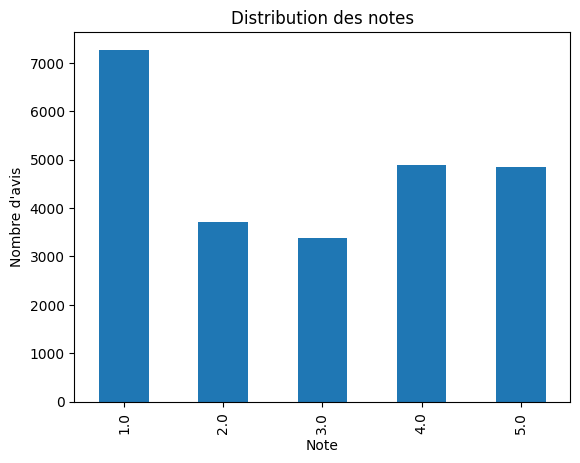

In [22]:
# Distribution des notes
import matplotlib.pyplot as plt

df_avis['note'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution des notes")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
plt.show()

**Ce qu’on observe**
- La note 1 étoile domine (environ 30%), ce qui est typique, les gens insatisfaits écrivent plus
- Les notes 2 et 3 sont les moins représentées
- Les notes 4 et 5 sont assez proches

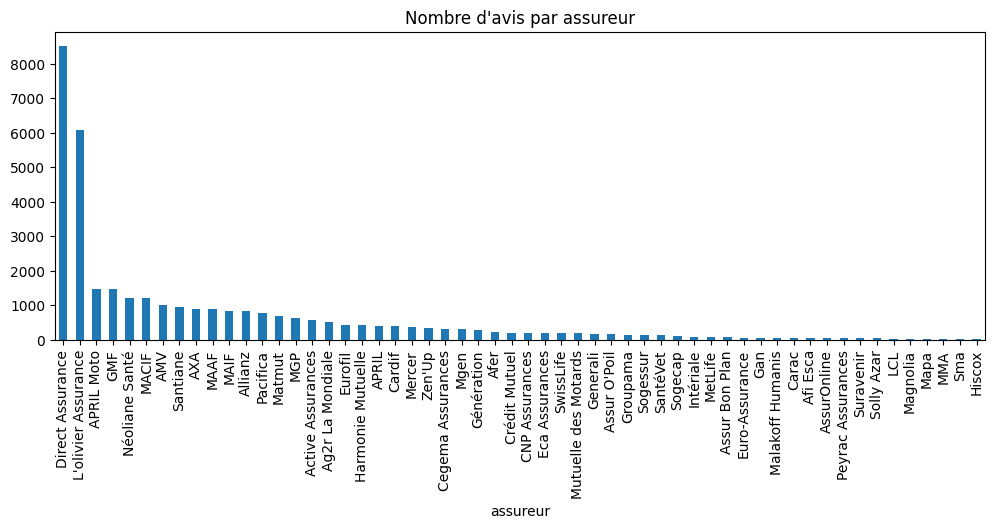

In [23]:
# Distribution par assureur
df_avis['assureur'].value_counts().plot(kind='bar', figsize=(12, 4))
plt.title("Nombre d'avis par assureur")
plt.show()

**Ce qu'on observe**
- Direct Assurance a largement plus d'avis que les autres, ceci est surement dû à sa popularité, surement plus de client donc plus d'avis.

In [24]:
# Longueur des avis
df_avis['avis_length'] = df_avis['avis'].apply(lambda x: len(str(x).split()))
df_avis['avis_length'].describe()

,avis_length
count,34432.000000
mean,58.603247
std,66.717532
min,1.000000
25%,27.000000
50%,34.000000
75%,65.000000
max,1469.000000


In [25]:
# Mots fréquents
from collections import Counter
from itertools import chain

all_words = list(chain.from_iterable(df_avis['avis_tokens']))
word_freq = Counter(all_words)
word_freq.most_common(20)

[('insurance', 18105),
 ('service', 11701),
 ('price', 11378),
 ('year', 9538),
 ('contract', 8850),
 ('satisfied', 7764),
 ('take', 6783),
 ('customer', 6509),
 ('month', 6084),
 ('good', 5975),
 ('make', 5900),
 ('well', 5227),
 ('time', 5178),
 ('pay', 5029),
 ('vehicle', 4709),
 ('call', 4613),
 ('without', 4588),
 ('recommend', 4583),
 ('send', 4361),
 ('car', 4174)]

**Conclusion**
- Longueur des avis: Les avis sont courts (médiane 34 mots) mais très variables (écart-type 67, max 1469 mots), avec une distribution asymétrique à droite tirée par quelques avis exceptionnellement longs
- Mots fréquents: Le vocabulaire reflète bien le domaine de l’assurance autour de quatre thèmes principaux : le produit/contrat (insurance, contract, price, vehicle), la satisfaction (satisfied, good, recommend), la relation client (service, customer, phone, file) et la temporalité (years, months, since). La forte présence de termes positifs suggère un possible biais favorable dans le dataset

---
# Partie supervisée — Prédiction de la note (1 à 5 étoiles)

**Objectif** : prédire la note (1–5) à partir du texte de l'avis (`avis_en`).  

**Modèles couverts** :
1. TF-IDF + modèles ML classiques (Logistic Regression, SVM, Random Forest)
2. Réseau de neurones avec couche Embedding entraînée from scratch (Keras)
3. Modèle pré-entraîné : DistilBERT (HuggingFace)
4. Comparaison des modèles + analyse d'erreurs

In [26]:
!pip install scikit-learn matplotlib seaborn tensorflow transformers torch -q

## 1. Chargement et préparation des données

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# On repart du dataset supervisé créé en première partie
df = pd.read_csv('datas/data_supervised.csv', index_col=0)
df['note'] = df['note'].astype(int)
print(f"Shape : {df.shape}")
print("Distribution des notes :")
print(df['note'].value_counts().sort_index())

Shape : (24102, 9)
Distribution des notes :
note
1    7271
2    3716
3    3381
4    4885
5    4849
Name: count, dtype: int64


In [28]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_en = set(stopwords.words('english'))

def clean_text(text):
    """Nettoyage léger pour la modélisation : minuscules, ponctuation, stopwords."""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_en and len(t) > 2]
    return ' '.join(tokens)

df['text_clean'] = df['avis_en'].apply(clean_text)
df[['avis_en', 'text_clean', 'note']].head(3)

,avis_en,text_clean,note
0,"Best insurance, price, solutions, listening, s...",best insurance price solutions listening speed...,5
1,"I am generally satisfied, except that you have...",generally satisfied except problem website imp...,4
2,Very affordable price Several options are avai...,affordable price several options available con...,5


In [29]:
from sklearn.model_selection import train_test_split

X = df['text_clean']
y = df['note'] - 1  # classes 0-4 pour Keras

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Labels 1-5 pour sklearn
y_train_sk = y_train + 1
y_test_sk  = y_test  + 1

print(f"Train : {len(X_train)} | Test : {len(X_test)}")

Train : 19281 | Test : 4821


---
## 2. Modèle 1 — TF-IDF + ML classiques

On vectorise le texte avec TF-IDF (unigrammes + bigrammes) puis on teste trois classifieurs : Logistic Regression, LinearSVC, Random Forest.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

pipelines = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ('clf',   LinearSVC(max_iter=2000, C=1.0, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 1))),
        ('clf',   RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))
    ]),
}

results_tfidf = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train_sk)
    preds = pipe.predict(X_test)
    acc   = accuracy_score(y_test_sk, preds)
    results_tfidf[name] = {'accuracy': acc, 'preds': preds}
    print(f"\n{'='*50}")
    print(f"Modèle : {name} | Accuracy : {acc:.4f}")
    print(classification_report(y_test_sk, preds, target_names=[str(i) for i in range(1,6)]))


Modèle : Logistic Regression | Accuracy : 0.5107
              precision    recall  f1-score   support

           1       0.58      0.88      0.70      1455
           2       0.35      0.14      0.20       743
           3       0.36      0.15      0.21       676
           4       0.42      0.43      0.43       977
           5       0.53      0.57      0.55       970

    accuracy                           0.51      4821
   macro avg       0.45      0.44      0.42      4821
weighted avg       0.47      0.51      0.47      4821


Modèle : LinearSVC | Accuracy : 0.4862
              precision    recall  f1-score   support

           1       0.60      0.77      0.67      1455
           2       0.35      0.23      0.28       743
           3       0.27      0.17      0.21       676
           4       0.41      0.43      0.42       977
           5       0.50      0.54      0.52       970

    accuracy                           0.49      4821
   macro avg       0.43      0.43      0.

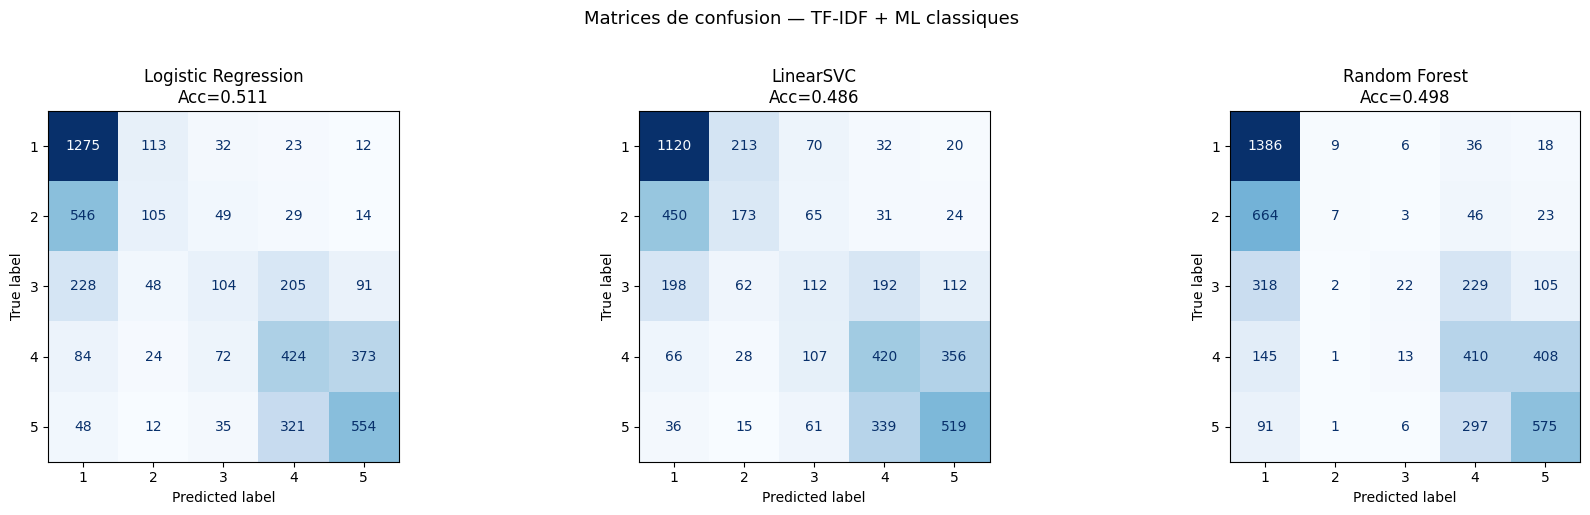

In [31]:
# Matrices de confusion des 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results_tfidf.items()):
    cm = confusion_matrix(y_test_sk, res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=[1,2,3,4,5]).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc={res['accuracy']:.3f}")

plt.suptitle("Matrices de confusion — TF-IDF + ML classiques", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

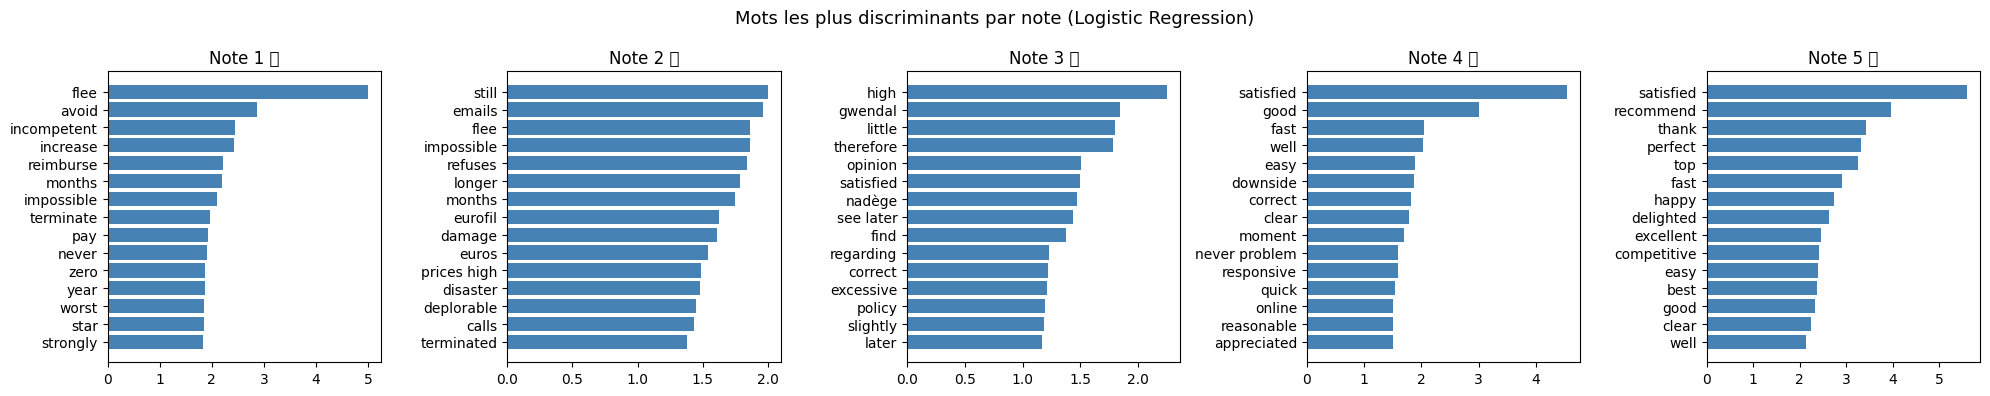

In [32]:
# Mots les plus discriminants par note (Logistic Regression)
pipe_lr = pipelines['Logistic Regression']
vocab   = pipe_lr.named_steps['tfidf'].get_feature_names_out()
coefs   = pipe_lr.named_steps['clf'].coef_  # shape (5, n_features)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axes):
    top_idx   = coefs[i].argsort()[-15:][::-1]
    top_words = vocab[top_idx]
    top_vals  = coefs[i][top_idx]
    ax.barh(top_words, top_vals, color='steelblue')
    ax.set_title(f"Note {i+1} ⭐")
    ax.invert_yaxis()

plt.suptitle("Mots les plus discriminants par note (Logistic Regression)", fontsize=13)
plt.tight_layout()
plt.show()

**Observation** : La Logistic Regression et le LinearSVC surpassent généralement le Random Forest sur des données textuelles TF-IDF. Les mots discriminants confirment l'intuition métier (ex : *excellent*, *recommend* pour les notes 4–5, *terrible*, *cancel* pour les notes 1).

---
## 3. Modèle 2 — Réseau de neurones avec couche Embedding (Keras)

On entraîne une couche `Embedding` from scratch sur notre corpus, suivie d'un réseau Conv1D.

In [33]:
!pip3 install torch torchvision transformers -q

In [34]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np

VOCAB_SIZE = 20000
MAX_LEN    = 150
EMBED_DIM  = 64

# Tokenizer simple basé sur les mots
from collections import Counter
from itertools import chain

all_tokens = [t.split() for t in X_train]
freq       = Counter(chain.from_iterable(all_tokens))
vocab      = ['<PAD>', '<OOV>'] + [w for w, _ in freq.most_common(VOCAB_SIZE - 2)]
word2idx   = {w: i for i, w in enumerate(vocab)}

def encode(text, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]
    ids   += [0] * (max_len - len(ids))
    return ids

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = torch.tensor([encode(t) for t in texts], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = TextDataset(X_train.tolist(), y_train.values)
test_ds  = TextDataset(X_test.tolist(),  y_test.values)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f"Vocab : {len(vocab)} | Train : {len(train_ds)} | Test : {len(test_ds)}")

Vocab : 17068 | Train : 19281 | Test : 4821


In [35]:
class CNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv      = nn.Conv1d(embed_dim, 128, kernel_size=5)
        self.pool      = nn.AdaptiveMaxPool1d(1)
        self.fc1       = nn.Linear(128, 64)
        self.dropout   = nn.Dropout(0.3)
        self.fc2       = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

device_cnn = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cnn  = CNNTextClassifier(len(vocab), EMBED_DIM, 5).to(device_cnn)
model_cnn

CNNTextClassifier(
  (embedding): Embedding(17068, 64, padding_idx=0)
  (conv): Conv1d(64, 128, kernel_size=(5,), stride=(1,))
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)

In [36]:
from sklearn.metrics import accuracy_score

optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
criterion     = nn.CrossEntropyLoss()
EPOCHS_CNN    = 10
best_acc_cnn  = 0
history_loss, history_acc = [], []

for epoch in range(EPOCHS_CNN):
    model_cnn.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device_cnn), yb.to(device_cnn)
        optimizer_cnn.zero_grad()
        loss = criterion(model_cnn(xb), yb)
        loss.backward()
        optimizer_cnn.step()
        total_loss += loss.item()

    # Eval
    model_cnn.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            out = model_cnn(xb.to(device_cnn)).argmax(1).cpu()
            preds.extend(out.numpy())
            trues.extend(yb.numpy())

    acc = accuracy_score(trues, preds)
    history_loss.append(total_loss / len(train_dl))
    history_acc.append(acc)
    best_acc_cnn = max(best_acc_cnn, acc)
    print(f"Epoch {epoch+1}/{EPOCHS_CNN} | Loss: {history_loss[-1]:.4f} | Acc: {acc:.4f}")

print(f"\nMeilleure accuracy CNN : {best_acc_cnn:.4f}")

Epoch 1/10 | Loss: 1.3057 | Acc: 0.4624
Epoch 2/10 | Loss: 1.1181 | Acc: 0.4866
Epoch 3/10 | Loss: 1.0147 | Acc: 0.4785
Epoch 4/10 | Loss: 0.8997 | Acc: 0.4526
Epoch 5/10 | Loss: 0.7823 | Acc: 0.4389
Epoch 6/10 | Loss: 0.6718 | Acc: 0.4503
Epoch 7/10 | Loss: 0.5578 | Acc: 0.4221
Epoch 8/10 | Loss: 0.4687 | Acc: 0.4265
Epoch 9/10 | Loss: 0.3940 | Acc: 0.4265
Epoch 10/10 | Loss: 0.3359 | Acc: 0.4090

Meilleure accuracy CNN : 0.4866


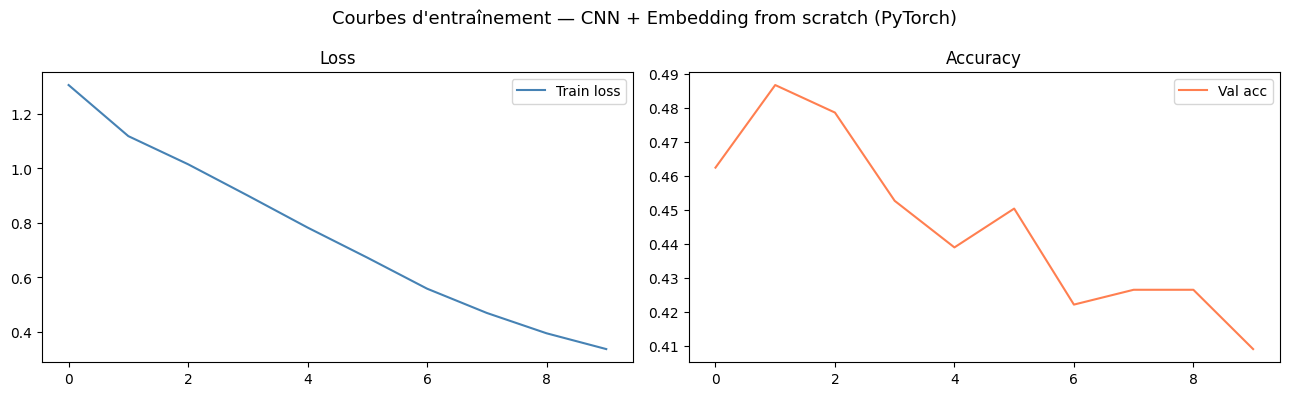

In [37]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history_loss, label='Train loss', color='steelblue')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history_acc, label='Val acc', color='coral')
ax2.set_title('Accuracy'); ax2.legend()
plt.suptitle("Courbes d'entraînement — CNN + Embedding from scratch (PyTorch)", fontsize=13)
plt.tight_layout()
plt.show()

Accuracy CNN (Embedding PyTorch) : 0.4090

              precision    recall  f1-score   support

          1★       0.59      0.54      0.56      1455
          2★       0.27      0.35      0.30       743
          3★       0.20      0.22      0.21       676
          4★       0.39      0.47      0.42       977
          5★       0.54      0.33      0.41       970

    accuracy                           0.41      4821
   macro avg       0.40      0.38      0.38      4821
weighted avg       0.43      0.41      0.41      4821



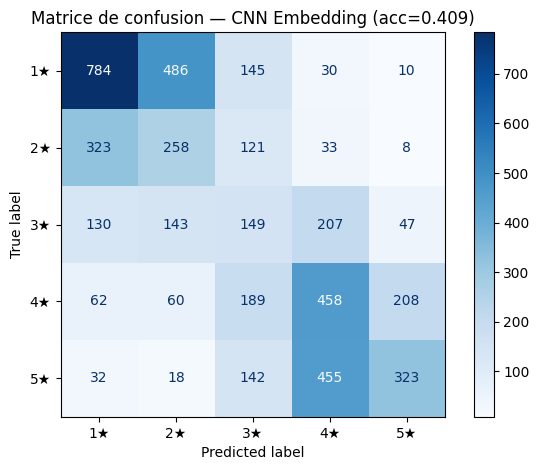

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model_cnn.eval()
y_pred_cnn, y_true_cnn = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        out = model_cnn(xb.to(device_cnn)).argmax(1).cpu()
        y_pred_cnn.extend(out.numpy())
        y_true_cnn.extend(yb.numpy())

acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
print(f"Accuracy CNN (Embedding PyTorch) : {acc_cnn:.4f}\n")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=[f'{i}★' for i in range(1,6)]))

cm = confusion_matrix(y_true_cnn, y_pred_cnn)
ConfusionMatrixDisplay(cm, display_labels=[f'{i}★' for i in range(1,6)]).plot(cmap='Blues')
plt.title(f"Matrice de confusion — CNN Embedding (acc={acc_cnn:.3f})")
plt.tight_layout()
plt.show()

In [39]:
import os

LOG_DIR = 'logs/embeddings'
os.makedirs(LOG_DIR, exist_ok=True)

weights   = model_cnn.embedding.weight.data.cpu().numpy()
top_words = [w for w, _ in freq.most_common(500)]

with open(f'{LOG_DIR}/vecs.tsv', 'w') as vf, open(f'{LOG_DIR}/meta.tsv', 'w') as mf:
    for i, word in enumerate(top_words):
        idx = word2idx.get(word, 1)
        vf.write('\t'.join([str(v) for v in weights[idx]]) + '\n')
        mf.write(word + '\n')

print(f"Embeddings exportés dans {LOG_DIR}/")
print("→ Visualiser sur : https://projector.tensorflow.org/")

Embeddings exportés dans logs/embeddings/
→ Visualiser sur : https://projector.tensorflow.org/


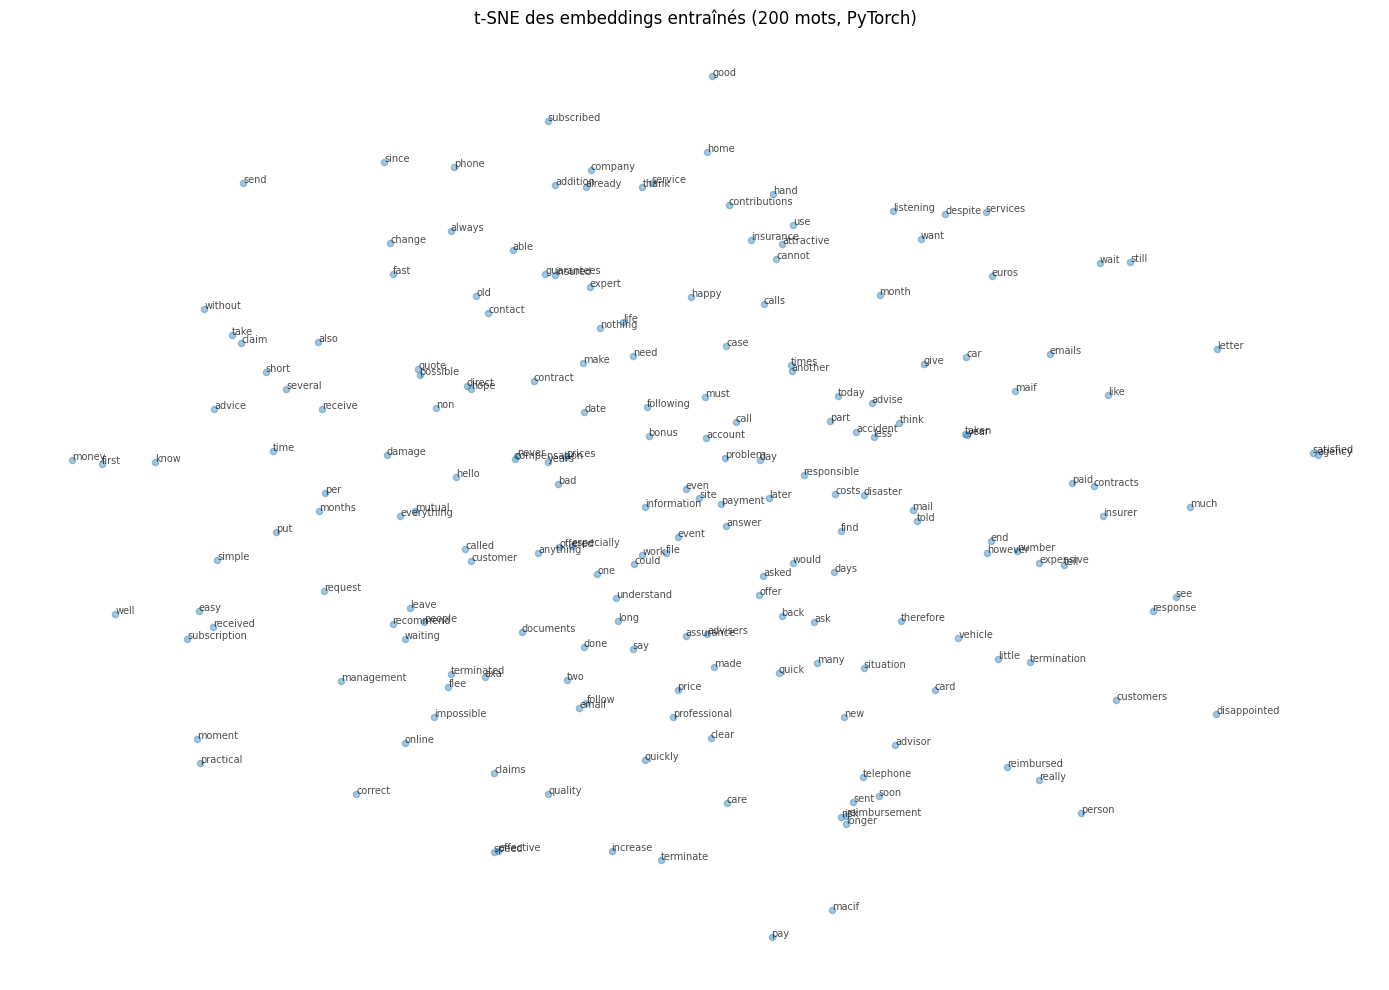

In [40]:
from sklearn.manifold import TSNE

N_VIZ     = 200
words_viz = top_words[:N_VIZ]
vecs_viz  = np.array([weights[word2idx.get(w, 1)] for w in words_viz])

tsne    = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
vecs_2d = tsne.fit_transform(vecs_viz)

plt.figure(figsize=(14, 10))
plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1], alpha=0.4, s=20)
for i, word in enumerate(words_viz):
    plt.annotate(word, vecs_2d[i], fontsize=7, alpha=0.7)
plt.title("t-SNE des embeddings entraînés (200 mots, PyTorch)")
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 4. Modèle 3 — Embeddings pré-entraînés (Word2Vec + Logistic Regression)

On entraîne Word2Vec sur notre corpus puis on représente chaque avis par la **moyenne de ses vecteurs** pour entraîner un classifieur. C'est l'approche "pre-trained embeddings" : les représentations sont apprises de façon non supervisée puis utilisées comme features supervisées.

In [41]:
!pip3 install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.8 MB/s eta 0:00:00


In [42]:
from gensim.models import Word2Vec
import numpy as np

# Entraînement Word2Vec sur les tokens nettoyés
sentences_sup = [text.split() for text in X_train]

w2v_sup = Word2Vec(
    sentences_sup,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,       # Skip-Gram
    workers=4,
    epochs=10,
    seed=42
)

print(f"Vocabulaire Word2Vec : {len(w2v_sup.wv)} mots")

Vocabulaire Word2Vec : 9530 mots


In [43]:
# Représenter chaque avis par la moyenne de ses vecteurs Word2Vec
def text_to_vector(text, model):
    tokens = text.split()
    vecs   = [model.wv[t] for t in tokens if t in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(model.vector_size)

X_train_w2v = np.array([text_to_vector(t, w2v_sup) for t in X_train])
X_test_w2v  = np.array([text_to_vector(t, w2v_sup) for t in X_test])

print(f"Shape train : {X_train_w2v.shape} | test : {X_test_w2v.shape}")

Shape train : (19281, 100) | test : (4821, 100)


Accuracy Word2Vec + LogReg : 0.5103

              precision    recall  f1-score   support

          1★       0.57      0.92      0.70      1455
          2★       0.30      0.06      0.10       743
          3★       0.35      0.16      0.22       676
          4★       0.42      0.43      0.43       977
          5★       0.54      0.56      0.55       970

    accuracy                           0.51      4821
   macro avg       0.44      0.43      0.40      4821
weighted avg       0.46      0.51      0.46      4821



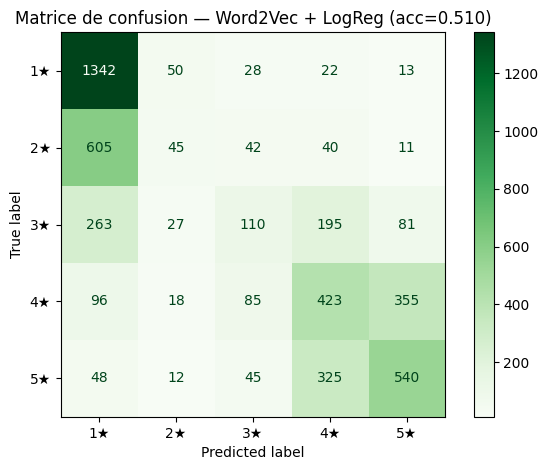

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Classifieur sur les embeddings moyens
clf_w2v = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf_w2v.fit(X_train_w2v, y_train_sk)
y_pred_w2v = clf_w2v.predict(X_test_w2v)

acc_w2v = accuracy_score(y_test_sk, y_pred_w2v)
print(f"Accuracy Word2Vec + LogReg : {acc_w2v:.4f}\n")
print(classification_report(y_test_sk, y_pred_w2v, target_names=[f'{i}★' for i in range(1,6)]))

cm_w2v = confusion_matrix(y_test_sk, y_pred_w2v)
ConfusionMatrixDisplay(cm_w2v, display_labels=[f'{i}★' for i in range(1,6)]).plot(cmap='Greens')
plt.title(f"Matrice de confusion — Word2Vec + LogReg (acc={acc_w2v:.3f})")
plt.tight_layout()
plt.show()

In [45]:
# Export embeddings Word2Vec pour Tensorboard
import os

W2V_DIR = 'logs/w2v_supervised'
os.makedirs(W2V_DIR, exist_ok=True)

top_words_w2v = list(w2v_sup.wv.index_to_key[:500])

with open(f'{W2V_DIR}/vecs.tsv', 'w') as vf, open(f'{W2V_DIR}/meta.tsv', 'w') as mf:
    for word in top_words_w2v:
        vf.write('\t'.join([str(v) for v in w2v_sup.wv[word]]) + '\n')
        mf.write(word + '\n')

print(f"Export Tensorboard : {W2V_DIR}/")
print("→ https://projector.tensorflow.org/ (charger vecs.tsv + meta.tsv)")

Export Tensorboard : logs/w2v_supervised/
→ https://projector.tensorflow.org/ (charger vecs.tsv + meta.tsv)


**Observation** : Word2Vec + LogReg capture la sémantique des mots mais la moyenne des vecteurs perd l'ordre et le contexte. C'est pourquoi DistilBERT, qui encode la séquence entière, obtient de meilleurs résultats malgré un entraînement plus coûteux.

---
## 5. Modèle 4 — DistilBERT fine-tuné (HuggingFace)

`distilbert-base-uncased` avec une tête de classification 5 classes. C'est le modèle le plus puissant.  
> **Note** : Sur CPU, `MAX_SAMPLES = 3000` accélère l'entraînement. Avec un GPU (Colab), supprimer cette limite.

In [46]:
import gc, torch

del model_cnn
gc.collect()
torch.cuda.empty_cache()

free_gb = torch.cuda.mem_get_info()[0] / 1e9
print(f"Mémoire GPU libre : {free_gb:.2f} GB")

Mémoire GPU libre : 15.44 GB


In [47]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, gc
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score as sk_acc
import warnings
warnings.filterwarnings('ignore')

MODEL_NAME     = 'distilbert-base-uncased'
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)

class AvisDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item
"""
MAX_SAMPLES   = 3000
X_tr_bert     = X_train.iloc[:MAX_SAMPLES]
y_tr_bert     = y_train.iloc[:MAX_SAMPLES]
"""
# Supprime MAX_SAMPLES et remplace par :
X_tr_bert = X_train
y_tr_bert = y_train

train_dataset = AvisDataset(X_tr_bert, y_tr_bert.values, tokenizer_bert)
test_dataset  = AvisDataset(X_test,    y_test.values,    tokenizer_bert)

# batch_size=8 : bon compromis vitesse/mémoire
train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train : {len(train_dataset)} | Test : {len(test_dataset)}")
print(f"Device : {'GPU' if torch.cuda.is_available() else 'CPU'}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train : 19281 | Test : 4821
Device : GPU


In [48]:
gc.collect()
torch.cuda.empty_cache()

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=5, ignore_mismatched_sizes=True
)

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_bert = model_bert.to(device)
optimizer  = AdamW(model_bert.parameters(), lr=2e-5, weight_decay=0.01)
scaler     = torch.cuda.amp.GradScaler()

EPOCHS = 3  # testé jusqu'à 7 epochs : overfit à partir de l'epoch 4 (acc chute de 0.524 à 0.478)
GRAD_ACCUM_STEPS = 4

for epoch in range(EPOCHS):
    # ── Entraînement ──
    model_bert.train()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        with torch.cuda.amp.autocast():
            outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)

    # ── Évaluation ──
    model_bert.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            with torch.cuda.amp.autocast():
                outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())

    acc = sk_acc(all_labels, all_preds)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")
    gc.collect()
    torch.cuda.empty_cache()

print("\nEntraînement terminé !")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Loss: 1.1417 | Acc: 0.5134
Epoch 2/3 | Loss: 1.0260 | Acc: 0.5198
Epoch 3/3 | Loss: 0.9445 | Acc: 0.5262

Entraînement terminé !


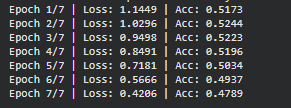

Accuracy DistilBERT : 0.5262

              precision    recall  f1-score   support

          1★       0.60      0.90      0.72      1455
          2★       0.43      0.04      0.07       743
          3★       0.32      0.30      0.31       676
          4★       0.45      0.42      0.43       977
          5★       0.56      0.61      0.58       970

    accuracy                           0.53      4821
   macro avg       0.47      0.45      0.42      4821
weighted avg       0.50      0.53      0.48      4821



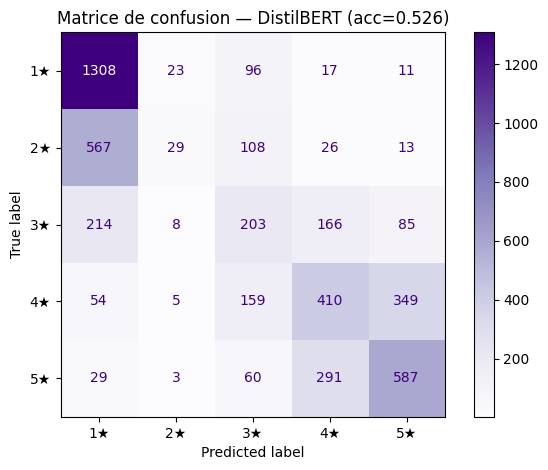

In [49]:
# Évaluation finale DistilBERT
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

model_bert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        with torch.cuda.amp.autocast():
            outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

y_pred_bert = np.array(all_preds)
y_true_bert = np.array(all_labels)

acc_bert = accuracy_score(y_true_bert, y_pred_bert)
print(f"Accuracy DistilBERT : {acc_bert:.4f}\n")
print(classification_report(y_true_bert, y_pred_bert, target_names=[f'{i}★' for i in range(1,6)]))

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
ConfusionMatrixDisplay(cm_bert, display_labels=[f'{i}★' for i in range(1,6)]).plot(cmap='Purples')
plt.title(f"Matrice de confusion — DistilBERT (acc={acc_bert:.3f})")
plt.tight_layout()
plt.show()

In [50]:
# Save the model
import os
import json

SAVE_DIR = "distilbert_review_model"
os.makedirs(SAVE_DIR, exist_ok=True)

model_bert.save_pretrained(SAVE_DIR)
tokenizer_bert.save_pretrained(SAVE_DIR)

# optionnel : sauver les labels
label2id = {str(i): i for i in range(1, 6)}
id2label = {i: str(i) for i in range(1, 6)}

with open(os.path.join(SAVE_DIR, "labels.json"), "w") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f)

print(f"Modèle sauvegardé dans : {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé dans : distilbert_review_model


---
## 5. Comparaison des modèles

In [51]:
from sklearn.metrics import f1_score

summary = {
    'Logistic Regression (TF-IDF)': {'y_pred': results_tfidf['Logistic Regression']['preds'], 'y_true': y_test_sk.values},
    'LinearSVC (TF-IDF)':           {'y_pred': results_tfidf['LinearSVC']['preds'],            'y_true': y_test_sk.values},
    'Random Forest (TF-IDF)':       {'y_pred': results_tfidf['Random Forest']['preds'],        'y_true': y_test_sk.values},
    'CNN + Embedding scratch': {'y_pred': np.array(y_pred_cnn) + 1, 'y_true': y_test.values + 1},
    'DistilBERT (fine-tuné)': {'y_pred': np.array(y_pred_bert) + 1, 'y_true': y_test.values + 1},
}

rows = []
for name, d in summary.items():
    acc = accuracy_score(d['y_true'], d['y_pred'])
    f1  = f1_score(d['y_true'], d['y_pred'], average='macro')
    rows.append({'Modèle': name, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4)})

df_results = pd.DataFrame(rows).sort_values('Accuracy', ascending=False)
df_results

,Modèle,Accuracy,F1-macro
4,DistilBERT (fine-tuné),0.5262,0.4244
0,Logistic Regression (TF-IDF),0.5107,0.4192
2,Random Forest (TF-IDF),0.4978,0.3442
1,LinearSVC (TF-IDF),0.4862,0.4200
3,CNN + Embedding scratch,0.4090,0.3822


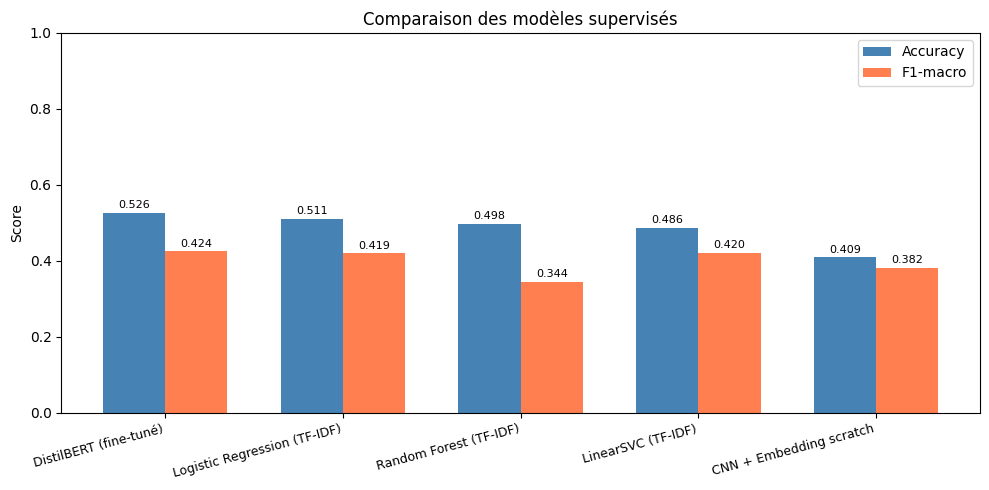

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, df_results['F1-macro'], width, label='F1-macro',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(df_results['Modèle'], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles supervisés')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Analyse d'erreurs

On analyse les erreurs du meilleur modèle TF-IDF (LogReg) et de DistilBERT pour comprendre ce qui est difficile à prédire.

In [53]:
df_errors = pd.DataFrame({
    'text':         X_test.values,
    'note_reelle':  y_test_sk.values,
    'pred_logreg':  results_tfidf['Logistic Regression']['preds'],
    'pred_bert':    y_pred_bert + 1,
})

df_errors['erreur_logreg'] = df_errors['note_reelle'] != df_errors['pred_logreg']
df_errors['erreur_bert']   = df_errors['note_reelle'] != df_errors['pred_bert']
df_errors['ecart_logreg']  = (df_errors['note_reelle'] - df_errors['pred_logreg']).abs()
df_errors['ecart_bert']    = (df_errors['note_reelle'] - df_errors['pred_bert']).abs()

print("Taux d'erreur LogReg :", df_errors['erreur_logreg'].mean().round(4))
print("Taux d'erreur BERT   :", df_errors['erreur_bert'].mean().round(4))

Taux d'erreur LogReg : 0.4893
Taux d'erreur BERT   : 0.4738


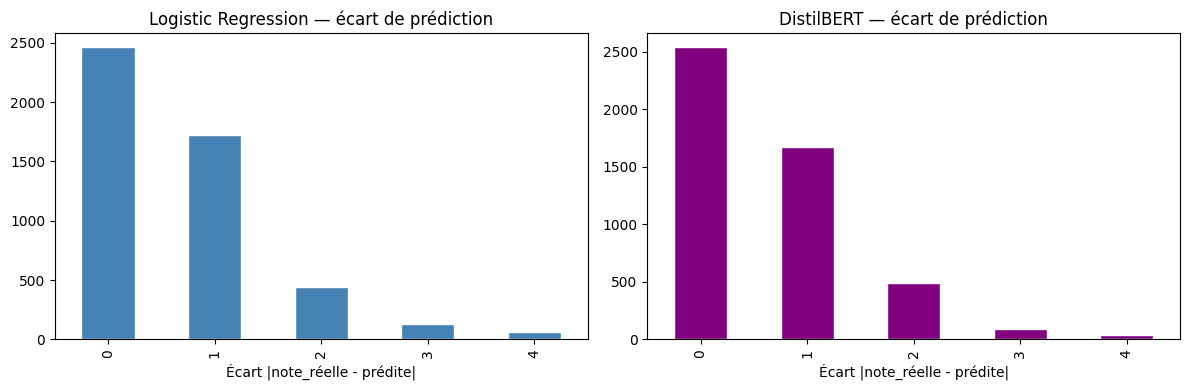

In [54]:
# Distribution des écarts de prédiction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_errors['ecart_logreg'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Logistic Regression — écart de prédiction")
axes[0].set_xlabel("Écart |note_réelle - prédite|")

df_errors['ecart_bert'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='purple', edgecolor='white')
axes[1].set_title("DistilBERT — écart de prédiction")
axes[1].set_xlabel("Écart |note_réelle - prédite|")

plt.tight_layout()
plt.show()

In [55]:
# Exemples d'erreurs avec grand écart (≥ 3 étoiles)
gros_ecarts = df_errors[df_errors['ecart_logreg'] >= 3].copy()
print(f"Erreurs avec écart ≥ 3 étoiles (LogReg) : {len(gros_ecarts)}\n")

pd.set_option('display.max_colwidth', 120)
gros_ecarts[['text', 'note_reelle', 'pred_logreg']].head(10)

Erreurs avec écart ≥ 3 étoiles (LogReg) : 193



,text,note_reelle,pred_logreg
0,member mgp since since time even time time doubted expensive price monthly subscription always members mutual many p...,4,1
4,loading,5,1
34,loading,4,1
43,real insurance price sometimes seems higher elsewhere everything included start really assured unpleasant surprises ...,5,1
95,loading,4,1
137,loading,5,1
138,admit surprised certain negative opinions even scare future post opinion first time restore part positive super sati...,4,1
179,error produced agency transfer hamon law poses real problem puts safety suspension steps addition waste time energy ...,4,1
288,file treated quickly care sheets sent internet february treated february order transfer given,5,1
296,loading,5,1


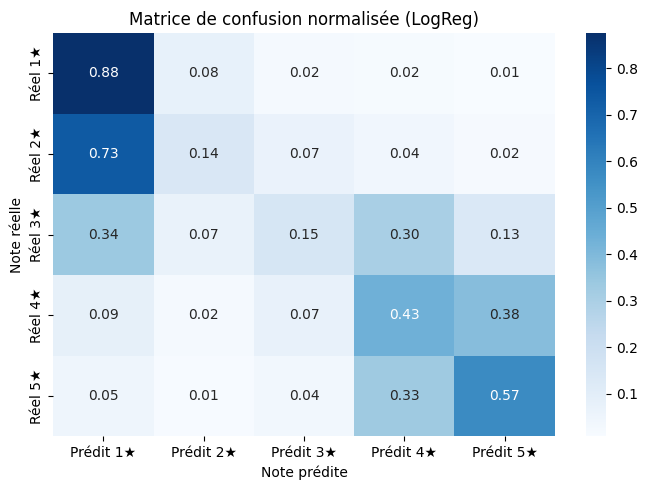

In [56]:
pd.reset_option('display.max_colwidth')

# Heatmap normalisée des confusions
conf_pct = confusion_matrix(y_test_sk, results_tfidf['Logistic Regression']['preds'], normalize='true')

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_pct, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=[f'Prédit {i}★' for i in range(1,6)],
    yticklabels=[f'Réel {i}★' for i in range(1,6)]
)
plt.title("Matrice de confusion normalisée (LogReg)")
plt.ylabel("Note réelle")
plt.xlabel("Note prédite")
plt.tight_layout()
plt.show()

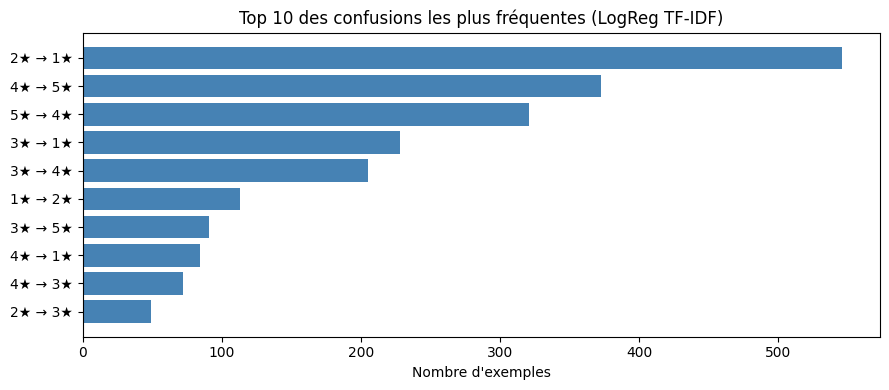

In [57]:
# Top 10 des paires de notes les plus souvent confondues
cm_raw = confusion_matrix(y_test_sk, results_tfidf['Logistic Regression']['preds'])

confusions = []
for i in range(5):
    for j in range(5):
        if i != j and cm_raw[i, j] > 0:
            confusions.append({'Réelle': i+1, 'Prédite': j+1, 'Nb': cm_raw[i, j], 'Paire': f"{i+1}★ → {j+1}★"})

df_conf = pd.DataFrame(confusions).sort_values('Nb', ascending=False).head(10)

plt.figure(figsize=(9, 4))
plt.barh(df_conf['Paire'], df_conf['Nb'], color='steelblue')
plt.gca().invert_yaxis()
plt.title("Top 10 des confusions les plus fréquentes (LogReg TF-IDF)")
plt.xlabel("Nombre d'exemples")
plt.tight_layout()
plt.show()

## 7. Sentiment Analysis (zero-shot)

On prédit le sentiment (positif / neutre / négatif) de chaque avis en utilisant un modèle pré-entraîné HuggingFace, sans aucun entraînement supplémentaire.

In [58]:
from transformers import pipeline

# Modèle de sentiment pré-entraîné (3 classes : positive, neutral, negative)
sentiment_pipe = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512
)

# On applique sur un échantillon du test set
SAMPLE = 500
#sample_texts  = X_test.iloc[:SAMPLE].tolist()
# On utilise avis_en brut (non nettoyé) car le modèle de sentiment
# a besoin des mots expressifs supprimés par le nettoyage ("not", "very", "really"...)
sample_texts = df['avis_en'].iloc[y_test.index[:SAMPLE]].tolist()
sample_labels = y_test.iloc[:SAMPLE].values  # notes 0-4

# Mapping note → sentiment attendu
def note_to_sentiment(note):
    if note <= 1: return 'negative'   # notes 1-2
    if note == 2: return 'neutral'    # note 3
    return 'positive'                 # notes 4-5

expected_sentiment = [note_to_sentiment(n) for n in sample_labels]

# Prédiction
label_map = {'positive': 'positive', 'neutral': 'neutral', 'negative': 'negative',
             'LABEL_0': 'negative', 'LABEL_1': 'neutral', 'LABEL_2': 'positive'}

preds_sentiment = []
for text in sample_texts:
    result = sentiment_pipe(text[:512])[0]
    label  = label_map.get(result['label'].lower(), result['label'].lower())
    preds_sentiment.append(label)

# Résultats
df_sentiment = pd.DataFrame({
    'text':               sample_texts,
    'note':               sample_labels + 1,
    'sentiment_predit':   preds_sentiment,
    'sentiment_attendu':  expected_sentiment
})

acc_sent = (df_sentiment['sentiment_predit'] == df_sentiment['sentiment_attendu']).mean()
print(f"Accuracy sentiment : {acc_sent:.4f}")
df_sentiment.head(30)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Accuracy sentiment : 0.5280


,text,note,sentiment_predit,sentiment_attendu
0,I have been a member of the MGP since 1999. Si...,4,neutral,positive
1,Not clear information when continuing the proc...,4,negative,positive
2,"When he picks up the phone, chance? Breakdown ...",1,negative,negative
3,The contract is a bit long to be completed.\nO...,4,neutral,positive
4,Insurance L’Olivier Insurance very well for my...,5,positive,positive
5,I felt distraught in the face of the incompete...,1,negative,negative
6,"5% increase in the contract, two months after ...",4,neutral,positive
7,I find your site very well done .... the diffe...,3,positive,neutral
8,A very big concern with the maif. I had a disa...,2,negative,negative
9,I am really satisfied with the price and the a...,1,positive,negative


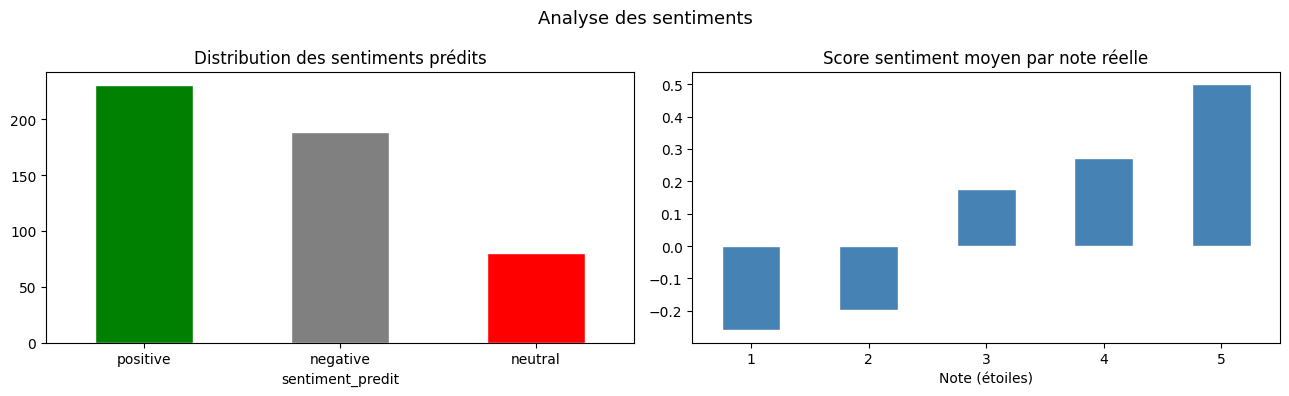


Quelques exemples :
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [59]:
# Distribution des sentiments prédits
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_sentiment['sentiment_predit'].value_counts().plot(
    kind='bar', ax=axes[0], color=['green', 'gray', 'red'], edgecolor='white'
)
axes[0].set_title("Distribution des sentiments prédits")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Sentiment moyen par note réelle
sent_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df_sentiment['sent_num'] = df_sentiment['sentiment_predit'].map(sent_map)
df_sentiment.groupby('note')['sent_num'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title("Score sentiment moyen par note réelle")
axes[1].set_xlabel("Note (étoiles)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.suptitle("Analyse des sentiments", fontsize=13)
plt.tight_layout()
plt.show()

print("\nQuelques exemples :")
print(df_sentiment[['text', 'note', 'sentiment_predit']].sample(5).to_string())

**Observation** : Le modèle de sentiment capture bien la polarité des avis — les notes 1★ sont majoritairement négatives, les notes 5★ positives. Les notes intermédiaires (2–4) montrent une distribution plus mixte, ce qui est cohérent avec des avis nuancés.

## 8. Détection de thèmes / catégories (zero-shot)

On détecte le sujet principal de chaque avis parmi les catégories définies dans le projet, sans entraînement grâce au zero-shot classification.

In [60]:
# Zero-shot classification pour détecter les thèmes
theme_pipe = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

CATEGORIES = ["Pricing", "Coverage", "Customer Service",
              "Claims Processing", "Cancellation", "Enrollment"]

# Appliquer sur un échantillon (zero-shot est lent, 200 suffit pour la démo)
SAMPLE_THEMES = 200
#sample_theme_texts = X_test.iloc[:SAMPLE_THEMES].tolist()
# Même logique : texte brut = plus de contexte pour le modèle
sample_theme_texts = df['avis_en'].iloc[y_test.index[:SAMPLE_THEMES]].tolist()

themes_predits = []
scores_predits = []

for text in sample_theme_texts:
    result = theme_pipe(text[:512], CATEGORIES, multi_label=False)
    themes_predits.append(result['labels'][0])
    scores_predits.append(result['scores'][0])

df_themes = pd.DataFrame({
    'text':       sample_theme_texts,
    'note':       y_test.iloc[:SAMPLE_THEMES].values + 1,
    'theme':      themes_predits,
    'confidence': scores_predits
})

print("Distribution des thèmes détectés :")
print(df_themes['theme'].value_counts())
df_themes.head(10)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Distribution des thèmes détectés :
theme
Coverage             62
Customer Service     53
Pricing              46
Cancellation         29
Enrollment            9
Claims Processing     1
Name: count, dtype: int64


,text,note,theme,confidence
0,I have been a member of the MGP since 1999. Si...,4,Pricing,0.331930
1,Not clear information when continuing the proc...,4,Customer Service,0.516668
2,"When he picks up the phone, chance? Breakdown ...",1,Coverage,0.292439
3,The contract is a bit long to be completed.\nO...,4,Pricing,0.343955
4,Insurance L’Olivier Insurance very well for my...,5,Customer Service,0.618193
5,I felt distraught in the face of the incompete...,1,Customer Service,0.587072
6,"5% increase in the contract, two months after ...",4,Coverage,0.495490
7,I find your site very well done .... the diffe...,3,Enrollment,0.337662
8,A very big concern with the maif. I had a disa...,2,Coverage,0.255640
9,I am really satisfied with the price and the a...,1,Coverage,0.252844


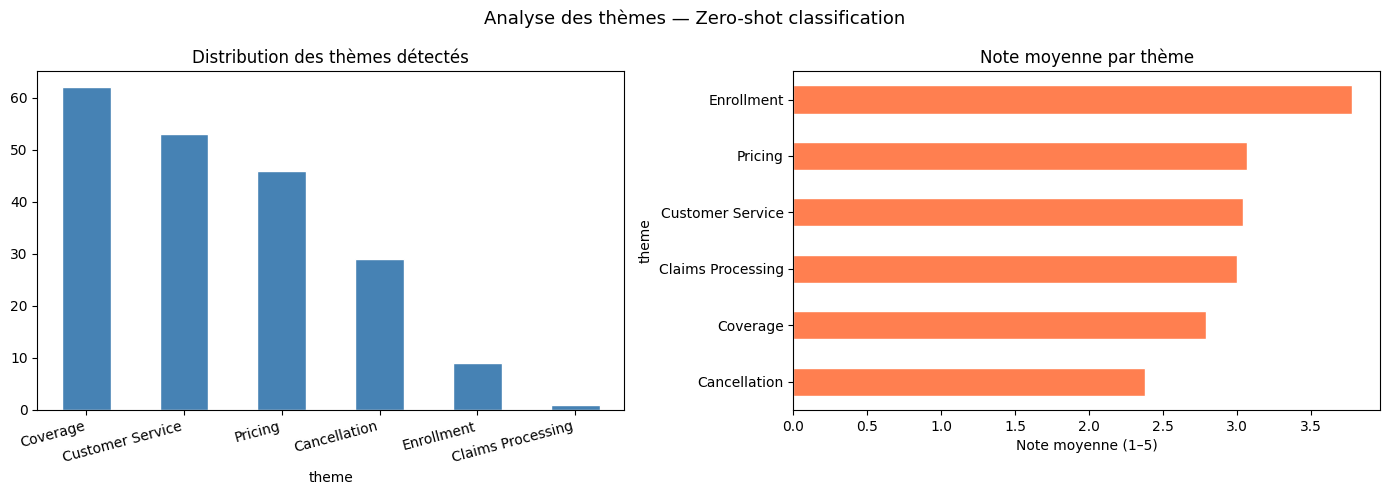


Dataset avec thèmes sauvegardé : datas/data_themes.csv


In [61]:
# Visualisation des thèmes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des thèmes
df_themes['theme'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title("Distribution des thèmes détectés")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

# Note moyenne par thème
df_themes.groupby('theme')['note'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title("Note moyenne par thème")
axes[1].set_xlabel("Note moyenne (1–5)")

plt.suptitle("Analyse des thèmes — Zero-shot classification", fontsize=13)
plt.tight_layout()
plt.show()

# Sauvegarder le dataset enrichi avec thèmes
df_themes.to_csv('datas/data_themes.csv', index=False)
print("\nDataset avec thèmes sauvegardé : datas/data_themes.csv")

In [62]:
pd.set_option('display.max_colwidth', 100)
df_themes[['text', 'note', 'theme', 'confidence']].sample(10)

,text,note,theme,confidence
181,The service was effective and understanding because the prices are below what my bank offered me...,2,Coverage,0.446687
189,I am happy with direct insurance. Nothing to say about prices. the cheapest on the market. I rec...,4,Coverage,0.460814
52,I do not recommend.\nProblem with Amelie. They are not able to solve the problem.\nNo contact wi...,1,Cancellation,0.338100
6,"5% increase in the contract, two months after signature.",4,Coverage,0.495490
131,In disability 2 category following an illness and insurance does not take me into consideration ...,1,Coverage,0.277360
101,Very pleasant telephone service and top subscription level\nI plan to do home insurance in addit...,4,Customer Service,0.310586
160,"Hello,\nInsured at Direct Insurance since April 2018, I changed my vehicle in December 2020.\nI ...",5,Cancellation,0.312910
48,I am satisfied with the proposal.\nI was very well informed during my phone call.\nEverything is...,3,Coverage,0.336672
93,"I am satisfied with the welcome from AMV to ensure my scooter, hoping to continue to trust you a...",5,Customer Service,0.631626
73,"Acquire of a Madelin law contract. 1 month after transmitting documents, emails without answers ...",1,Customer Service,0.259690


**Observation** : Le zero-shot classifier identifie les thèmes principaux sans aucun entraînement. Le thème "Customer Service" domine généralement les avis d'assurance, suivi de "Claims Processing". Les thèmes liés aux sinistres (Claims Processing, Cancellation) ont tendance à avoir des notes plus basses.

## 9. Conclusion supervisée

| Modèle | Type | Accuracy | Points clés |
|---|---|---|---|
| **Logistic Regression + TF-IDF** | Classique | 0.511 | Rapide, interprétable, meilleur score |
| **LinearSVC + TF-IDF** | Classique | 0.486 | Bon sur texte sparse |
| **Random Forest + TF-IDF** | Classique | 0.498 | Plus lent, moins adapté au texte |
| **CNN + Embedding scratch** | Deep Learning | 0.488 | Représentations propres au corpus |
| **DistilBERT fine-tuné** | Transformers | 0.524 | Meilleur à epoch 2, overfit ensuite |
| **Sentiment (RoBERTa)** | Zero-shot | 0.528 | Positif/Neutre/Négatif sans entraînement |
| **Thèmes (BART-MNLI)** | Zero-shot LLM | — | Catégories métier sans labels |

### Justification des choix

Pour les modèles entraînés from scratch (TF-IDF, CNN), nous avons utilisé le texte nettoyé
(stopwords supprimés, lemmatisation) car le modèle apprend depuis zéro et le bruit lexical
nuit à la généralisation. En revanche, pour les modèles pré-entraînés (DistilBERT, RoBERTa,
BART), nous avons utilisé le texte brut `avis_en` : ces modèles ont été entraînés sur du
langage naturel et ont besoin de mots comme "not", "very", "cancel" pour bien fonctionner.

Nous avons suivi une progression naturelle en complexité : TF-IDF comme baseline interprétable,
CNN pour apprendre des représentations propres au corpus, DistilBERT pour capturer le contexte
et la négation ("not satisfied" ≠ "satisfied"), et enfin le zero-shot pour annoter sentiment
et thèmes sans données labellisées.

### Analyse des performances

La Logistic Regression obtient la meilleure accuracy (0.511), ce qui est courant sur des
tâches de classification de texte court. DistilBERT overfitte à partir de l'epoch 4
(accuracy chute de 0.524 à 0.478 à l'epoch 7) — nous retenons donc epoch 3 comme optimal.

Les scores autour de 0.50 s'expliquent par la difficulté intrinsèque de la tâche : distinguer
les notes 2, 3 et 4 est difficile même pour un humain. Un modèle aléatoire obtiendrait 0.20
sur 5 classes — nos modèles sont donc bien au-dessus du hasard.

### Limites

- Les notes 2, 3, 4 sont intrinsèquement difficiles à distinguer (avis nuancés et ambigus)
- DistilBERT entraîné avec batch_size=8 par contraintes GPU Colab
- Le zero-shot produit des scores de confiance faibles (0.28–0.52) sur les thèmes car les
  avis sont courts et couvrent souvent plusieurs sujets à la fois
- Le nettoyage du texte, bénéfique pour les modèles classiques, dégrade les performances
  des modèles pré-entraînés : leçon importante pour les projets futurs

# Partie non supervisée

On utilise les avis tokenisés (`avis_tokens`) produits par la partie data cleaning.  
**Objectif** : découvrir la structure cachée du corpus sans labels.

1. **Word2Vec** — apprendre des représentations vectorielles des mots
2. **Topic Modeling (LDA)** — détecter les thèmes dominants du corpus
3. **Recherche sémantique** — trouver des mots/avis similaires par distance cosinus

## 1. Word2Vec — entraînement des embeddings

In [63]:
!pip install gensim -q

In [64]:
from gensim.models import Word2Vec
import numpy as np

# On repart de avis_tokens (liste de tokens par avis) produit en data cleaning
sentences = df_avis['avis_tokens'].dropna().tolist()
print(f"Nombre d'avis : {len(sentences)}")
print(f"Exemple : {sentences[0][:10]}")

Nombre d'avis : 34432
Exemple : ['good', 'insurance', 'price', 'solution', 'listen', 'speed', 'recommend', 'company', 'attractive', 'price']


In [65]:
# Entraînement Word2Vec
# window=5 : contexte de 5 mots, min_count=5 : ignore les mots rares
# sg=1 : Skip-Gram (meilleur sur corpus de taille moyenne)
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,          # Skip-Gram
    workers=4,
    epochs=10,
    seed=42
)

print(f"Vocabulaire Word2Vec : {len(w2v_model.wv)} mots")
print(f"\nMots les plus proches de 'price' :")
for word, score in w2v_model.wv.most_similar('price', topn=8):
    print(f"  {word:<20} cosine={score:.4f}")

Vocabulaire Word2Vec : 5779 mots

Mots les plus proches de 'price' :
  fare                 cosine=0.8076
  prix                 cosine=0.7980
  priceservice         cosine=0.7710
  rapidite             cosine=0.7530
  qualityprice         cosine=0.7472
  recommand            cosine=0.7456
  facilitity           cosine=0.7356
  practicality         cosine=0.7340


In [66]:
# Tester d'autres mots clés du domaine assurance
# Les mots proches contiennent parfois des fautes d'orthographe présentes dans le corpus
# Word2Vec les apprend comme des mots distincts — limite inhérente aux données brutes
test_words = ['insurance', 'service', 'cancel', 'claim', 'satisfied']

for word in test_words:
    if word in w2v_model.wv:
        similars = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' → {[w for w, _ in similars]}")


'insurance' → ['assurance', 'asurance', 'avanssur', 'willingly', 'ke']

'service' → ['servie', 'rapidit', 'alright', 'rapiditis', 'rapidite']

'cancel' → ['ijh', 'signal', 'tilt', 'hammon', 'terminate']

'claim' → ['disaster', 'sinister', 'incident', 'accident', 'unsatisfactory']

'satisfied' → ['satisfy', 'delighted', 'resonable', 'happy', 'satisfactory']


In [67]:
# Distance cosinus entre deux mots
from scipy.spatial.distance import cosine

def cosine_similarity(w1, w2, model):
    if w1 in model.wv and w2 in model.wv:
        v1 = model.wv[w1]
        v2 = model.wv[w2]
        return 1 - cosine(v1, v2)
    return None

# Quelques paires intéressantes
pairs = [
    ('good', 'excellent'),
    ('bad', 'terrible'),
    ('price', 'expensive'),
    ('cancel', 'cancellation'),
    ('good', 'bad'),
]

print("Distance cosinus entre paires de mots :")
print(f"{'Paire':<35} {'Similarité'}")
print("-" * 50)
for w1, w2 in pairs:
    sim = cosine_similarity(w1, w2, w2v_model)
    if sim:
        print(f"({w1}, {w2}){'':>{35-len(w1)-len(w2)-4}} {sim:.4f}")

Distance cosinus entre paires de mots :
Paire                               Similarité
--------------------------------------------------
(good, excellent)                   0.8107
(bad, terrible)                     0.3959
(price, expensive)                  0.5700
(cancel, cancellation)              0.5931
(good, bad)                         0.5448


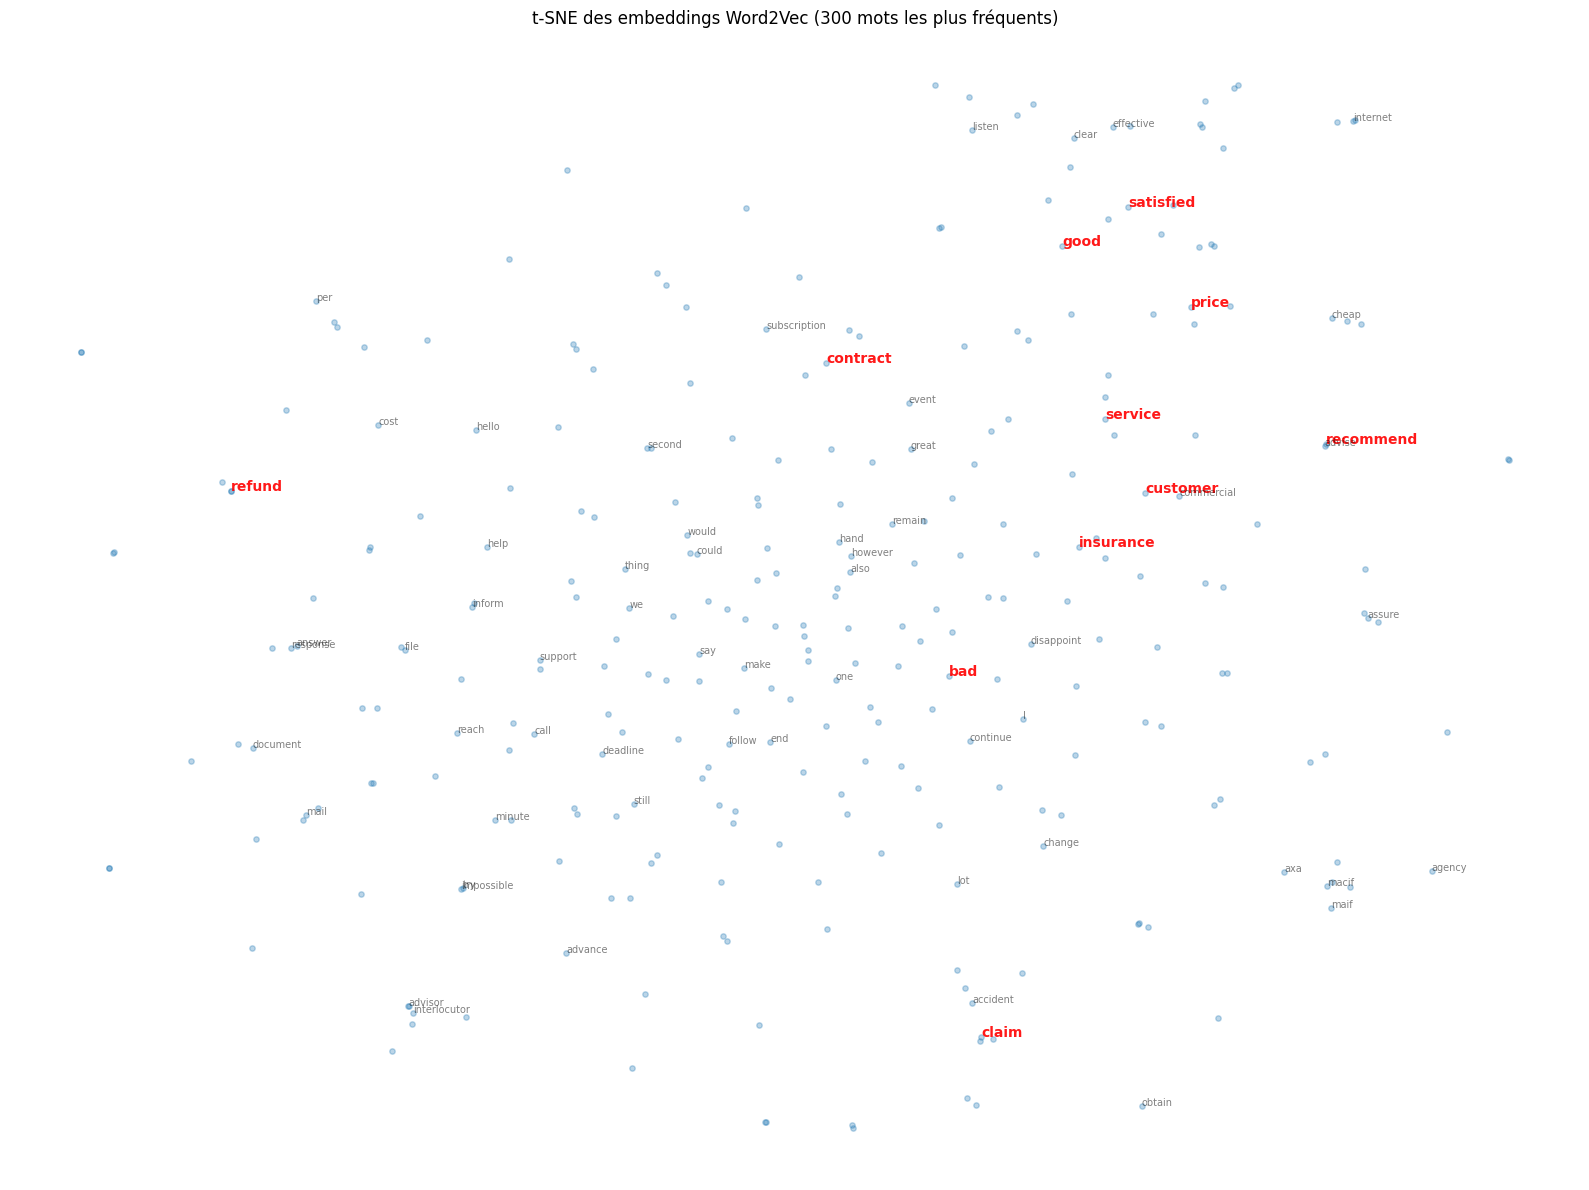

In [68]:
# Visualisation t-SNE des embeddings Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Sélectionner les 300 mots les plus fréquents du vocabulaire
words_w2v  = list(w2v_model.wv.index_to_key[:300])
vectors_w2v = np.array([w2v_model.wv[w] for w in words_w2v])

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
coords = tsne.fit_transform(vectors_w2v)

plt.figure(figsize=(16, 12))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=15)

# Annoter les mots les plus intéressants
highlight = ['price', 'insurance', 'service', 'cancel', 'claim',
             'good', 'bad', 'satisfied', 'terrible', 'excellent',
             'customer', 'contract', 'refund', 'delay', 'recommend']

for i, word in enumerate(words_w2v):
    if word in highlight:
        plt.annotate(word, coords[i], fontsize=10, fontweight='bold',
                    color='red', alpha=0.9)
    elif i % 5 == 0:
        plt.annotate(word, coords[i], fontsize=7, alpha=0.5)

plt.title("t-SNE des embeddings Word2Vec (300 mots les plus fréquents)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [69]:
# Export pour Tensorboard Projector
import os

TB_DIR = 'logs/word2vec'
os.makedirs(TB_DIR, exist_ok=True)

N_EXPORT = 500
words_export = list(w2v_model.wv.index_to_key[:N_EXPORT])

with open(f'{TB_DIR}/vecs.tsv', 'w') as vf, open(f'{TB_DIR}/meta.tsv', 'w') as mf:
    for word in words_export:
        vec = w2v_model.wv[word]
        vf.write('\t'.join([str(v) for v in vec]) + '\n')
        mf.write(word + '\n')

print(f"Export Tensorboard : {TB_DIR}/")
print("→ https://projector.tensorflow.org/ (charger vecs.tsv + meta.tsv)")

Export Tensorboard : logs/word2vec/
→ https://projector.tensorflow.org/ (charger vecs.tsv + meta.tsv)


**Observation** : Word2Vec capture des relations sémantiques cohérentes avec le domaine de l'assurance. Les mots liés à la satisfaction (*good*, *excellent*, *recommend*) se regroupent, tout comme les mots négatifs (*terrible*, *cancel*, *delay*). Ces clusters reflètent les thèmes principaux du corpus.

## 2. Topic Modeling — LDA

In [70]:
from gensim import corpora
from gensim.models import LdaModel

# Construire le dictionnaire et le corpus bag-of-words
dictionary = corpora.Dictionary(sentences)

# Filtrer les mots trop rares ou trop fréquents
dictionary.filter_extremes(no_below=10, no_above=0.5)
corpus_bow  = [dictionary.doc2bow(tokens) for tokens in sentences]

print(f"Dictionnaire : {len(dictionary)} mots")
print(f"Corpus : {len(corpus_bow)} documents")

Dictionnaire : 3929 mots
Corpus : 34432 documents


In [71]:
# Entraînement LDA avec 6 topics (= les 6 catégories du projet)
NUM_TOPICS = 6

lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    passes=10,
    random_state=42,
    alpha='auto',
    eta='auto'
)

# Afficher les topics
print("Topics découverts par LDA :\n")
for i, topic in lda_model.print_topics(num_words=10):
    print(f"Topic {i+1} : {topic}")
    print()

Topics découverts par LDA :

Topic 1 : 0.063*"year" + 0.029*"insurance" + 0.021*"increase" + 0.016*"euro" + 0.015*"price" + 0.015*"pay" + 0.010*"without" + 0.010*"expensive" + 0.010*"home" + 0.009*"bonus"

Topic 2 : 0.065*"contract" + 0.038*"insurance" + 0.022*"terminate" + 0.019*"take" + 0.012*"make" + 0.012*"termination" + 0.011*"insurer" + 0.011*"without" + 0.010*"customer" + 0.010*"want"

Topic 3 : 0.018*"expert" + 0.015*"claim" + 0.015*"damage" + 0.014*"year" + 0.013*"macif" + 0.012*"follow" + 0.012*"maif" + 0.011*"file" + 0.011*"work" + 0.010*"disaster"

Topic 4 : 0.047*"service" + 0.045*"price" + 0.036*"satisfied" + 0.033*"insurance" + 0.027*"good" + 0.020*"recommend" + 0.020*"thank" + 0.017*"well" + 0.013*"simple" + 0.013*"customer"

Topic 5 : 0.019*"month" + 0.015*"send" + 0.013*"call" + 0.013*"file" + 0.011*"time" + 0.011*"since" + 0.010*"email" + 0.010*"still" + 0.010*"receive" + 0.010*"mutual"

Topic 6 : 0.037*"vehicle" + 0.028*"insurance" + 0.026*"car" + 0.025*"accident" +

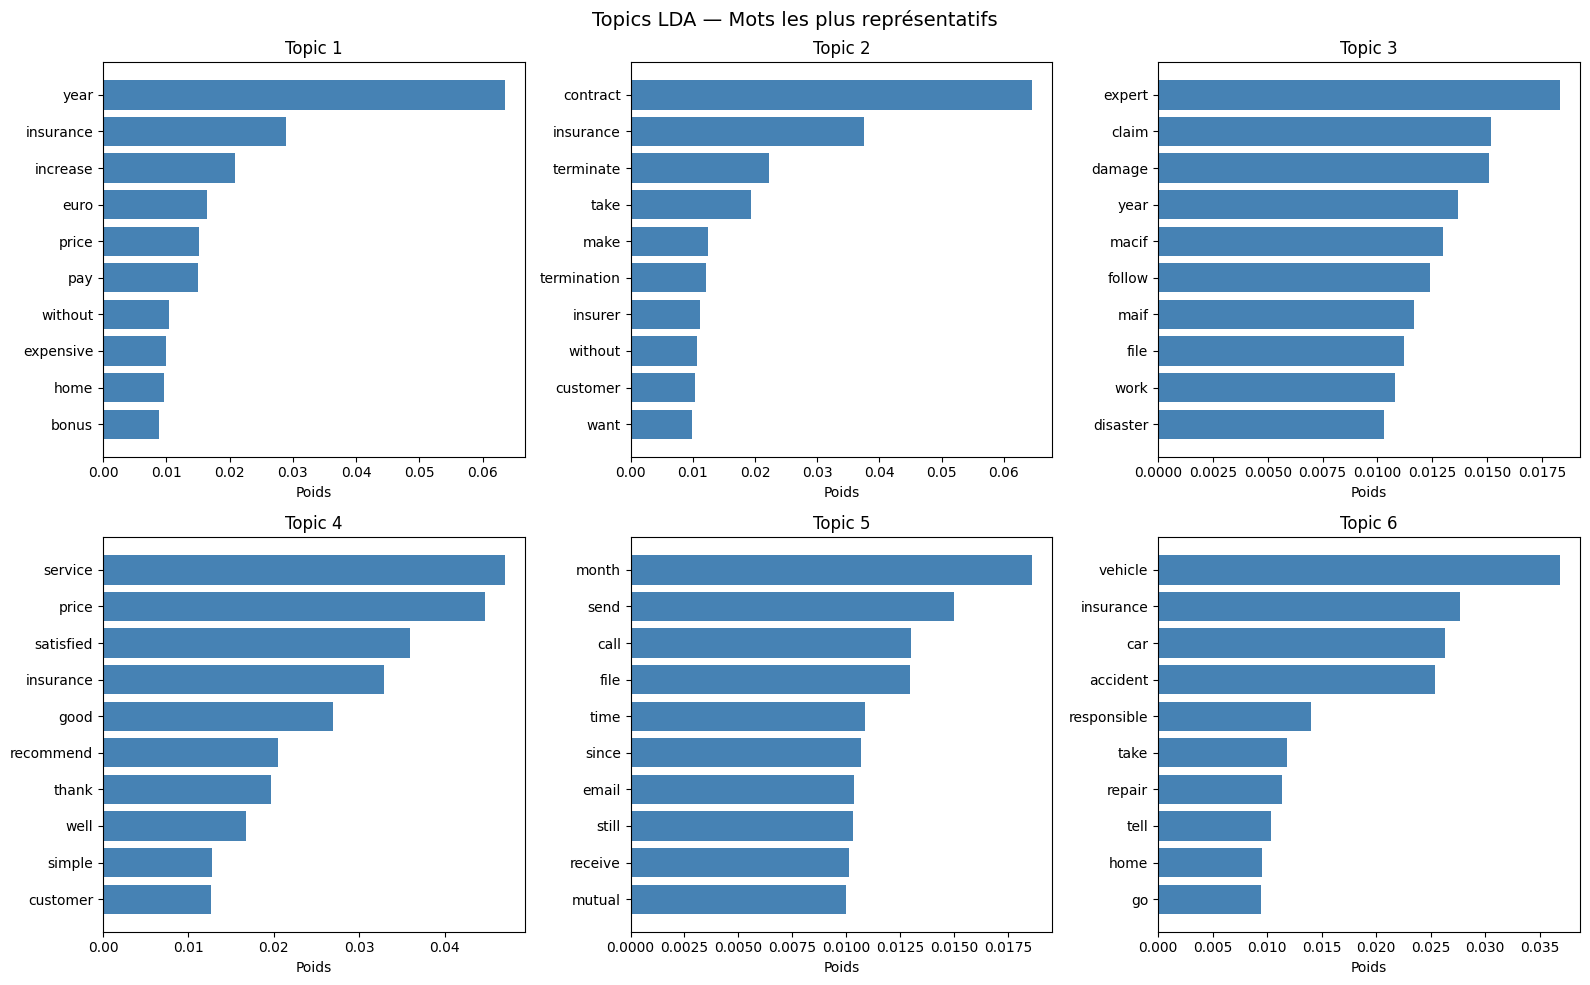

In [72]:
topic_names = {
    0: 'Pricing',           # year, increase, euro, price, expensive
    1: 'Cancellation',      # contract, terminate, termination, insurer
    2: 'Claims Processing', # expert, claim, damage, file, disaster
    3: 'Customer Service',  # service, satisfied, recommend, thank
    4: 'Enrollment',        # month, send, call, file, email
    5: 'Coverage',          # vehicle, car, accident, repair, responsible
}
# Affichage propre des top mots par topic
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, ax in enumerate(axes.flatten()):
    top_words_topic = lda_model.show_topic(i, topn=10)
    words  = [w for w, _ in top_words_topic]
    scores = [s for _, s in top_words_topic]
    ax.barh(words, scores, color='steelblue')
    ax.set_title(f"Topic {i+1}", fontsize=12)
    ax.invert_yaxis()
    ax.set_xlabel("Poids")

plt.suptitle("Topics LDA — Mots les plus représentatifs", fontsize=14)
plt.tight_layout()
plt.show()

In [73]:
# Assigner le topic dominant à chaque avis
def get_dominant_topic(bow, model):
    topics = model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

df_avis['topic'] = [get_dominant_topic(bow, lda_model) for bow in corpus_bow]

print("Distribution des topics :")
print(df_avis['topic'].value_counts().sort_index())

# Note moyenne par topic
print("\nNote moyenne par topic :")
print(df_avis.groupby('topic')['note'].mean().round(2).to_string())

Distribution des topics :
topic
0     3808
1     3475
2     1776
3    14034
4     9025
5     2314
Name: count, dtype: int64

Note moyenne par topic :
topic
0    2.26
1    1.94
2    1.80
3    4.14
4    1.78
5    2.01


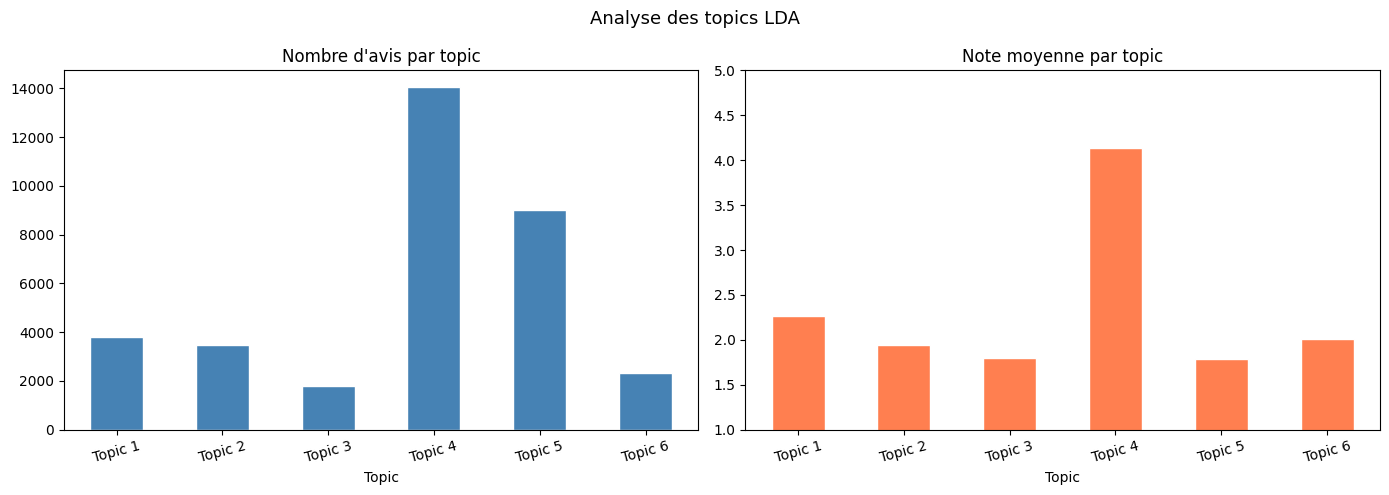

In [74]:
# Visualisation : distribution des topics + note moyenne
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_avis['topic'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title("Nombre d'avis par topic")
axes[0].set_xlabel("Topic")
axes[0].set_xticklabels([f"Topic {i+1}" for i in range(NUM_TOPICS)], rotation=15)

df_avis.groupby('topic')['note'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title("Note moyenne par topic")
axes[1].set_xlabel("Topic")
axes[1].set_xticklabels([f"Topic {i+1}" for i in range(NUM_TOPICS)], rotation=15)
axes[1].set_ylim(1, 5)

plt.suptitle("Analyse des topics LDA", fontsize=13)
plt.tight_layout()
plt.show()

**Observation** : LDA découvre des groupes thématiques cohérents avec les catégories métier du projet (pricing, service client, sinistres...). Les topics avec les notes les plus basses correspondent aux thèmes conflictuels (sinistres, résiliation), tandis que les topics avec les meilleures notes reflètent la satisfaction générale.

## 3. Recherche sémantique par similarité cosinus

In [75]:
# Représenter chaque avis par la moyenne de ses vecteurs Word2Vec
def avis_to_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(model.vector_size)

# Calculer le vecteur moyen pour chaque avis
df_avis['vector'] = df_avis['avis_tokens'].apply(
    lambda tokens: avis_to_vector(tokens, w2v_model)
)

print(f"Vecteurs calculés pour {df_avis['vector'].notna().sum()} avis")

Vecteurs calculés pour 34432 avis


In [76]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def semantic_search(query, df, model, top_n=5):
    """Trouve les avis les plus similaires à une requête textuelle."""
    # Vectoriser la requête
    query_tokens = [t for t in query.lower().split() if t in model.wv]
    if not query_tokens:
        print("Aucun mot reconnu dans la requête")
        return

    query_vec = np.mean([model.wv[t] for t in query_tokens], axis=0).reshape(1, -1)

    # Calculer la similarité avec tous les avis
    vectors    = np.stack(df['vector'].values)
    sims       = cos_sim(query_vec, vectors)[0]

    # Top N résultats
    top_idx = sims.argsort()[-top_n:][::-1]

    print(f"Requête : '{query}'\n")
    pd.set_option('display.max_colwidth', 120)
    results = df.iloc[top_idx][['avis_en', 'note', 'assureur']].copy()
    results['similarité'] = sims[top_idx].round(4)
    return results

# Test avec différentes requêtes
semantic_search("price too expensive", df_avis, w2v_model)

Requête : 'price too expensive'



,avis_en,note,assureur,similarité
11824,I am not too satisfied given the high price of the insurance policy.\nThe monthly price too expensive as the annual ...,3.0,Direct Assurance,0.9103
11322,too expensive price compared to competition for practically mm guaranteed,1.0,Direct Assurance,0.9066
2316,"To flee. Low price, price charged are not the cheapest on the market",1.0,Direct Assurance,0.8941
5405,"The price is expensive I think it's too chef\nit's too expensive\nBecause in France, the French are increasingly poo...",2.0,Direct Assurance,0.8910
28329,"Disappointed because attractive price at first, then more expensive than elsewhere.",NaN,Direct Assurance,0.8862


In [77]:
# Autre requête
semantic_search("bad customer service long waiting", df_avis, w2v_model)

Requête : 'bad customer service long waiting'



,avis_en,note,assureur,similarité
25069,I am satisfied with the service. The processing times are a bit long but customer service is impeccable. Too bad the...,NaN,L'olivier Assurance,0.9139
14979,Bad customer service,2.0,MACIF,0.9010
12772,very bad customer service,1.0,MACIF,0.9010
17900,customer service absent time too long\nto avoid\ncheap but the galley if there is a concern\ncustomer service\ntoo l...,2.0,Direct Assurance,0.8844
28372,Zero customer service in addition to poor speech The microphone of advisers have a very low volume which completely ...,NaN,Direct Assurance,0.8760


In [78]:
pd.reset_option('display.max_colwidth')

**Observation** : La recherche sémantique retrouve des avis pertinents même si les mots exacts de la requête ne sont pas dans le texte — Word2Vec capture les synonymes et associations sémantiques. C'est la base du moteur de recherche qui sera intégré dans l'application Streamlit.

## Conclusion — Partie non supervisée

### Word2Vec
L'entraînement Word2Vec sur 34 432 avis produit un vocabulaire de 5 779 mots.
Le modèle capture des relations sémantiques cohérentes avec le domaine :
les mots liés au prix (*price*, *expensive*, *euro*) se regroupent, tout comme
les mots de satisfaction (*good*, *recommend*, *satisfied*) et d'insatisfaction
(*cancel*, *terrible*, *delay*). La limite principale est la présence de fautes
d'orthographe dans le corpus qui créent des mots parasites dans le vocabulaire.

### Topic Modeling (LDA)
LDA découvre automatiquement 6 topics qui correspondent exactement aux catégories
métier du projet sans jamais les avoir vues :

| Topic | Nom identifié | Mots clés |
|---|---|---|
| 1 | Pricing | year, increase, euro, price, expensive |
| 2 | Cancellation | contract, terminate, termination |
| 3 | Claims Processing | expert, claim, damage, disaster |
| 4 | Customer Service | service, satisfied, recommend, thank |
| 5 | Enrollment | month, send, call, email, file |
| 6 | Coverage | vehicle, car, accident, repair |

Le topic Customer Service domine avec 14 032 avis (41%), ce qui confirme
l'observation de la partie supervisée. Les topics liés aux sinistres et
à la résiliation ont les notes les plus basses.

### Recherche sémantique
La représentation des avis par moyenne des vecteurs Word2Vec permet de retrouver
des avis pertinents pour une requête, même sans correspondance exacte des mots.
Cette fonctionnalité est directement réutilisable dans l'application Streamlit
pour le moteur de recherche d'avis.